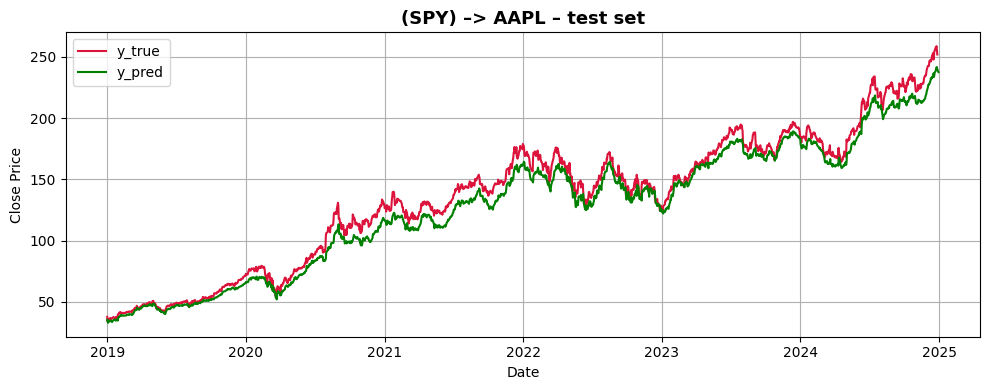

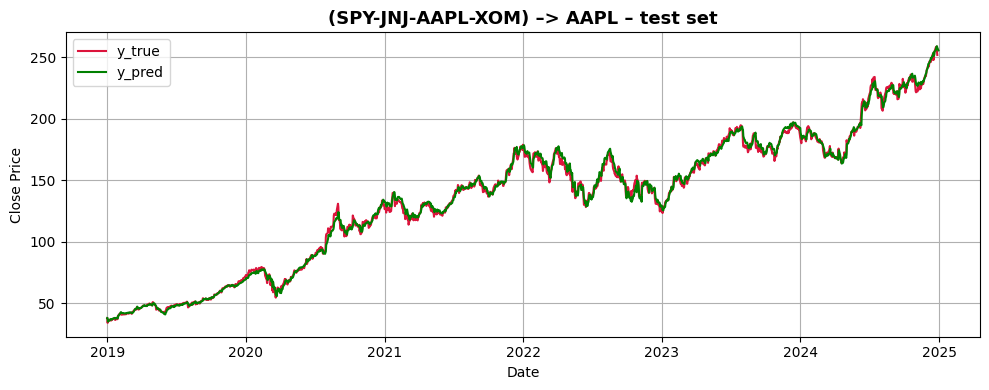

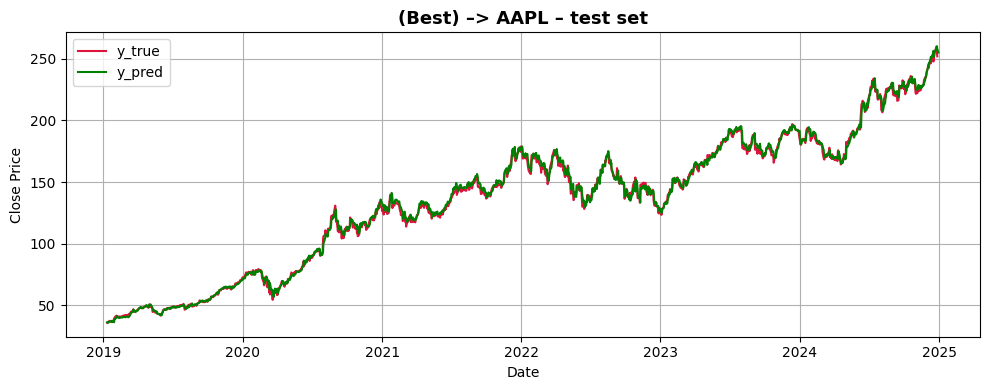

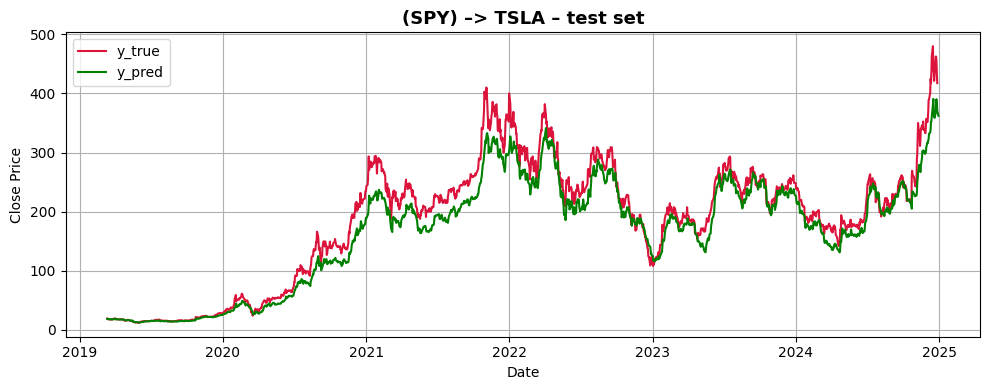

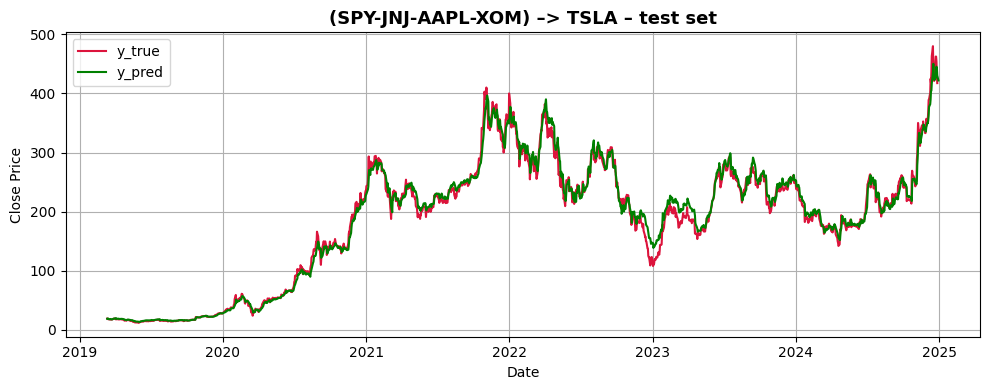

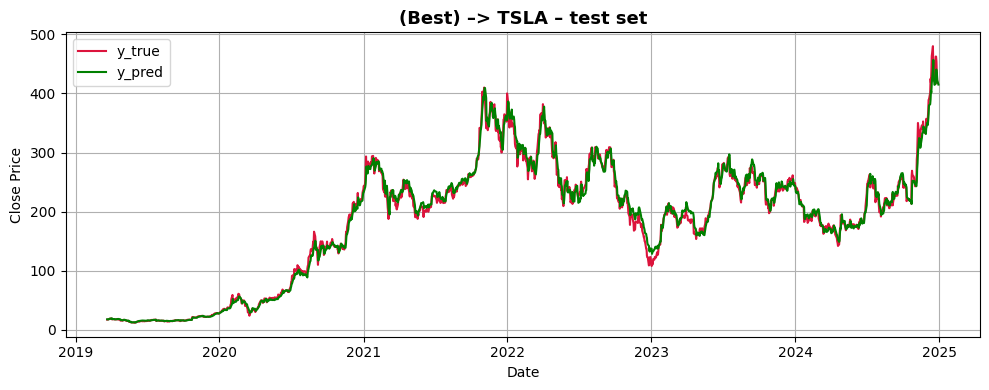

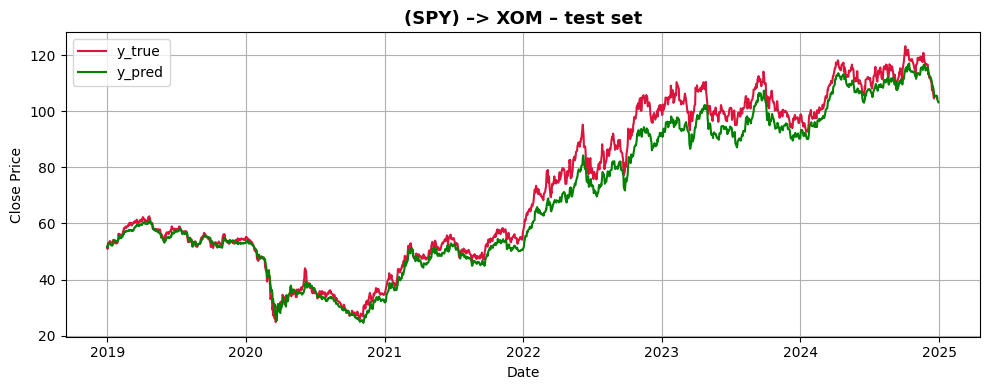

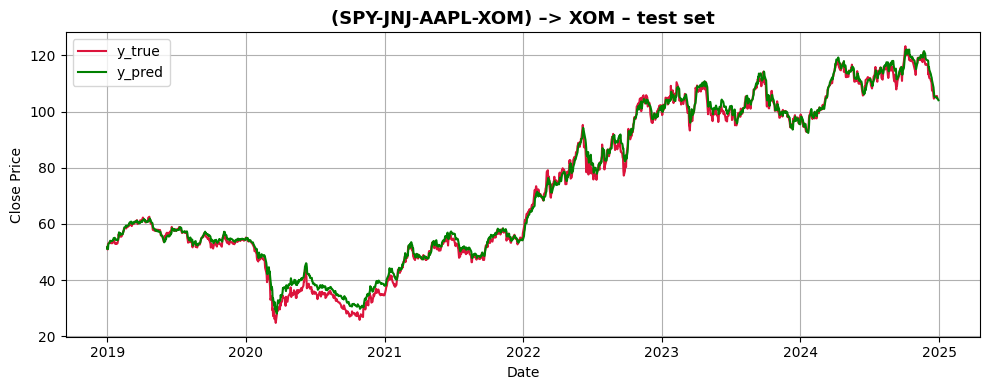

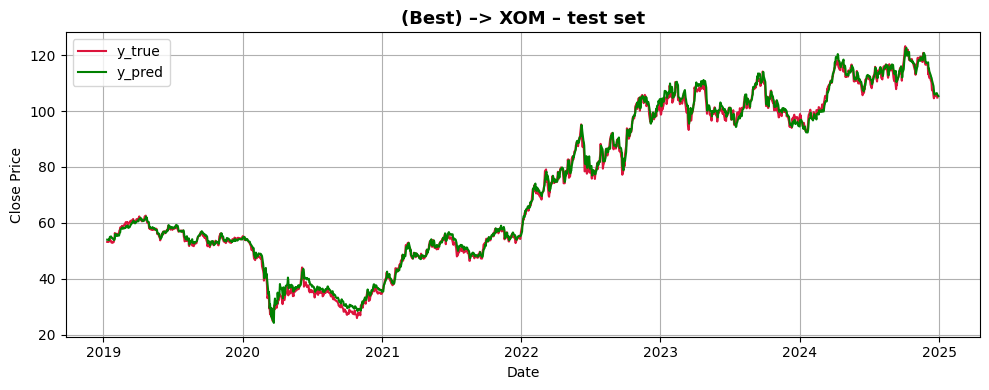

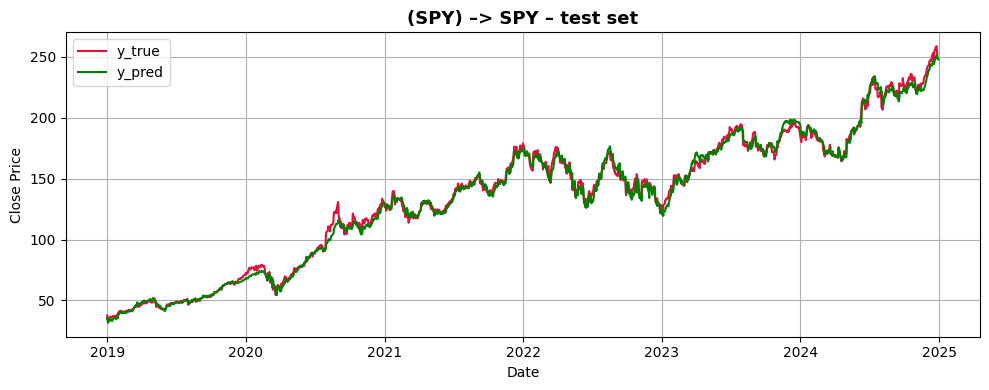

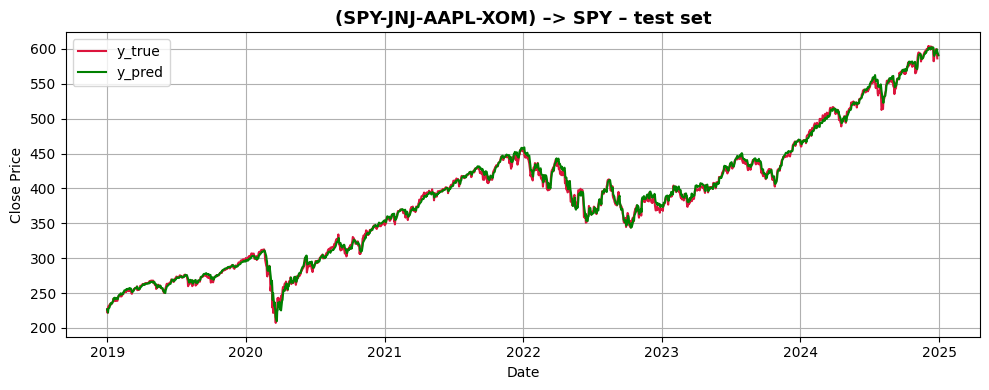

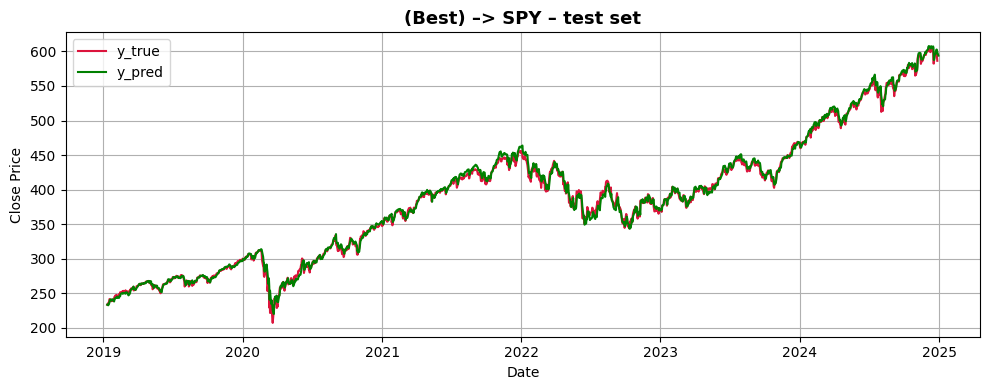

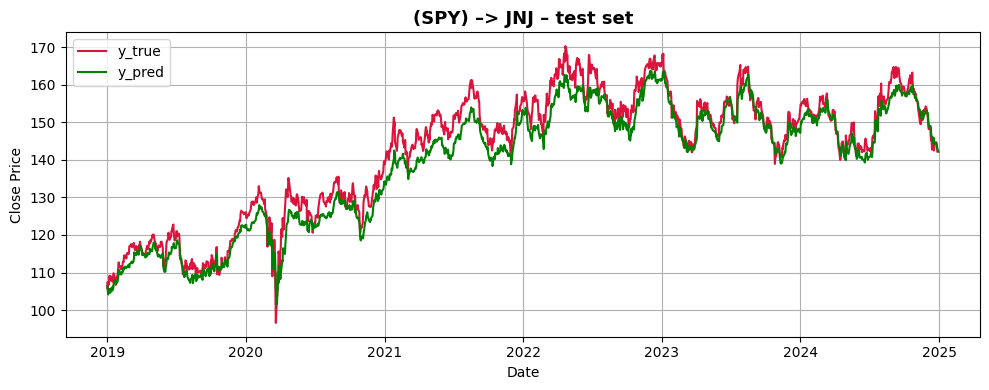

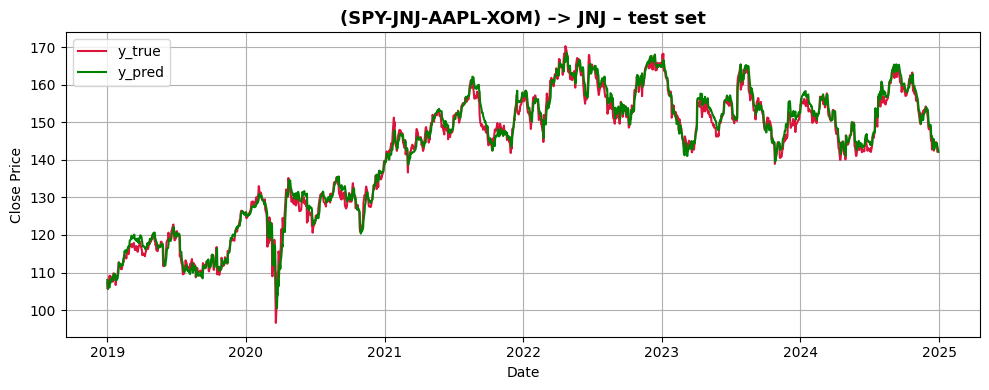

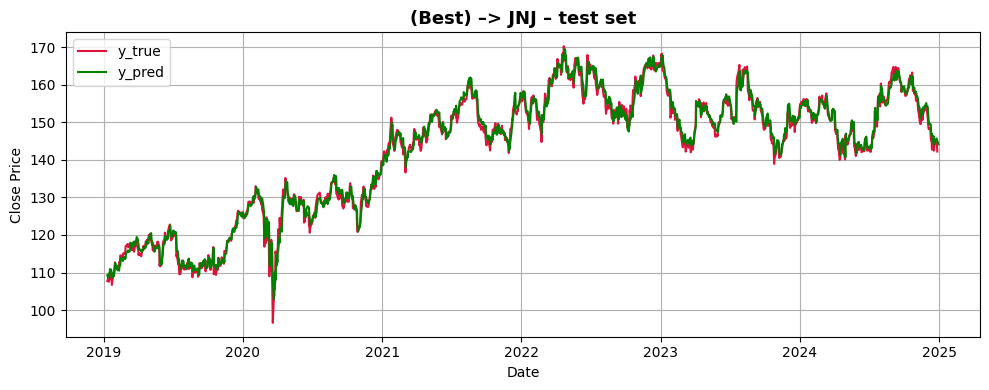

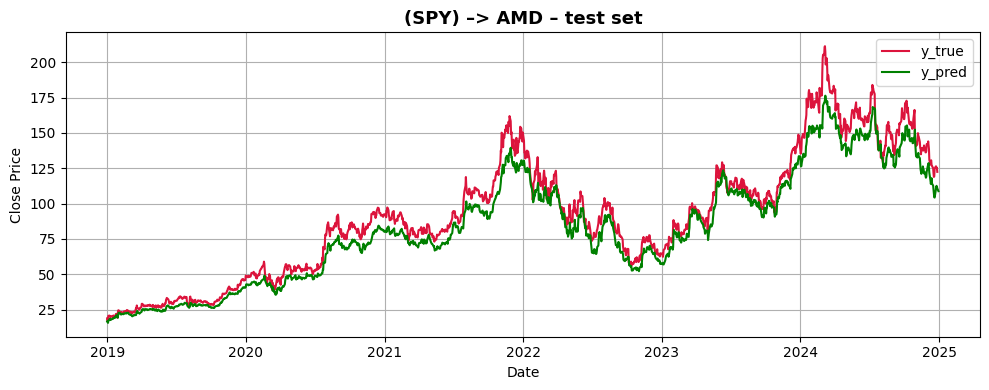

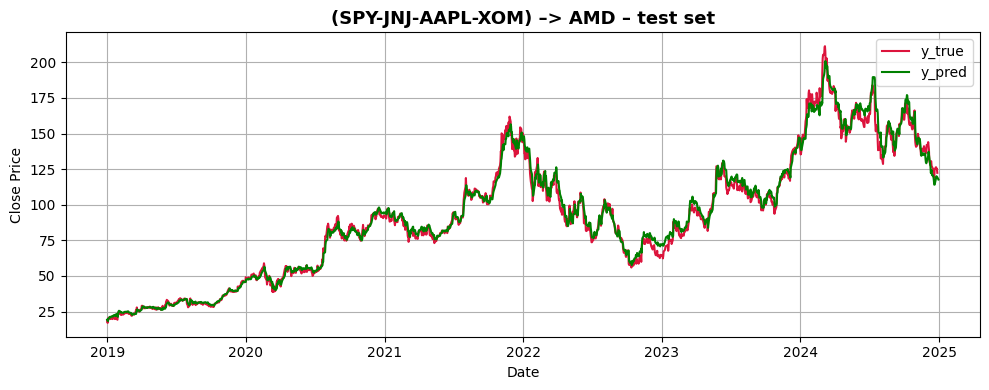

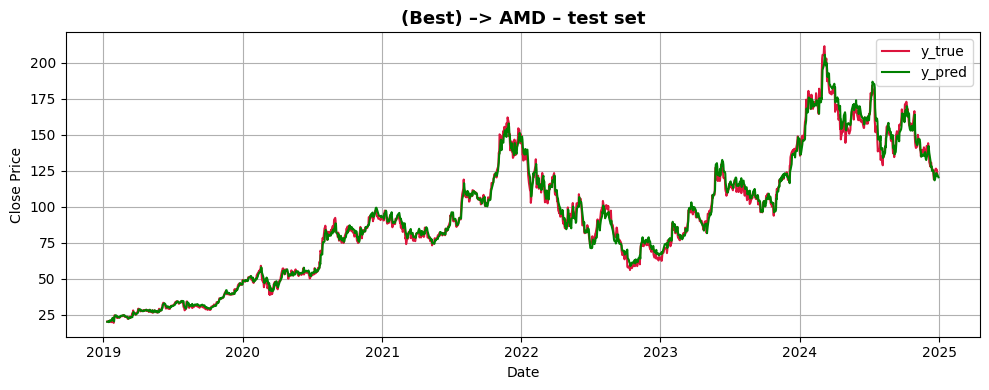

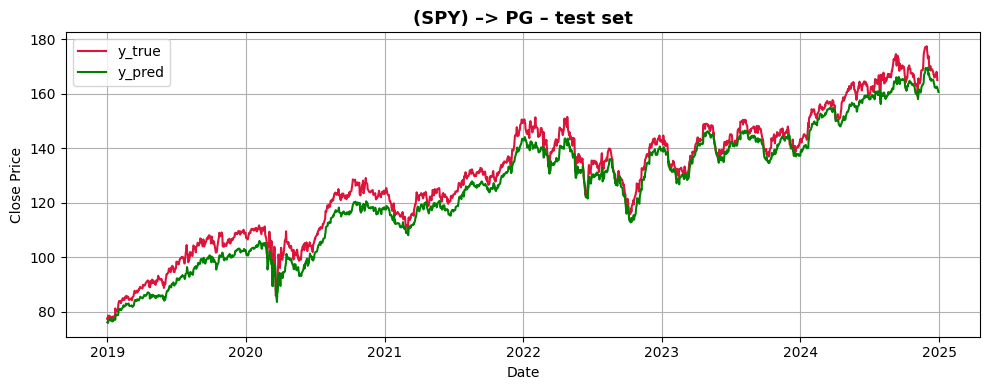

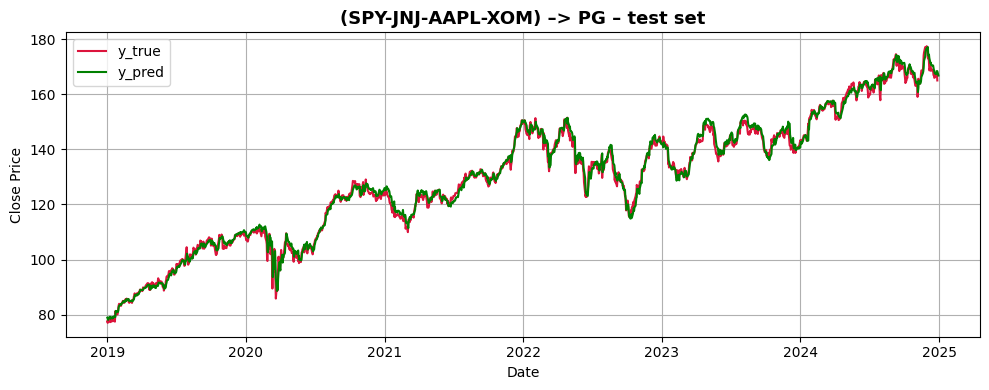

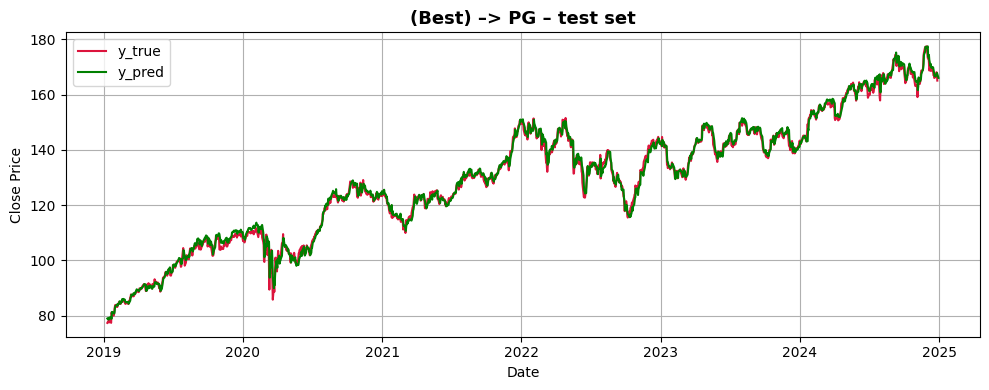

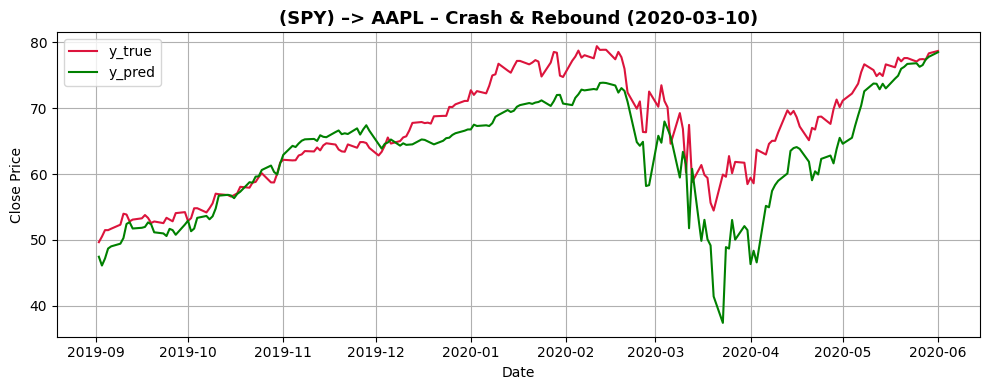

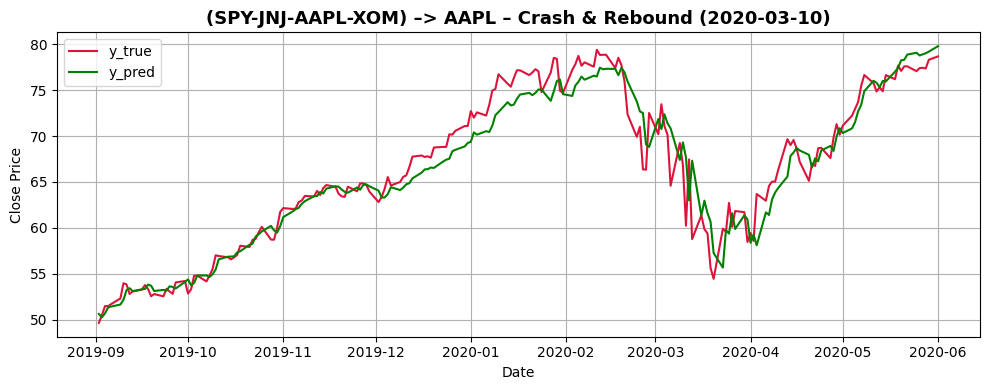

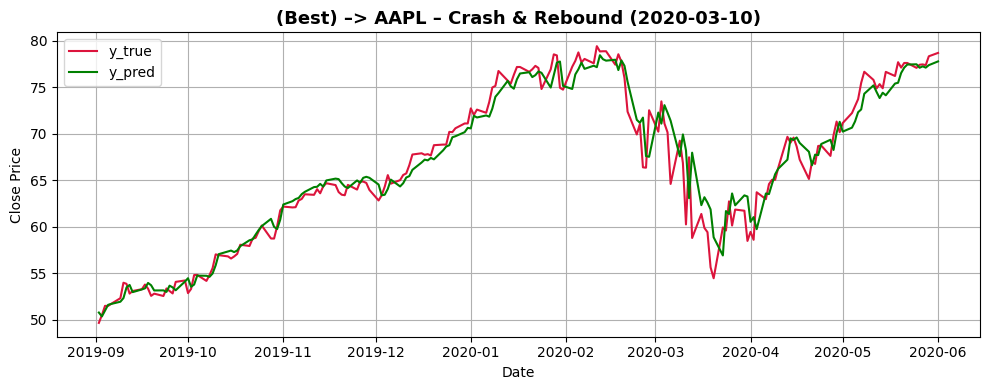

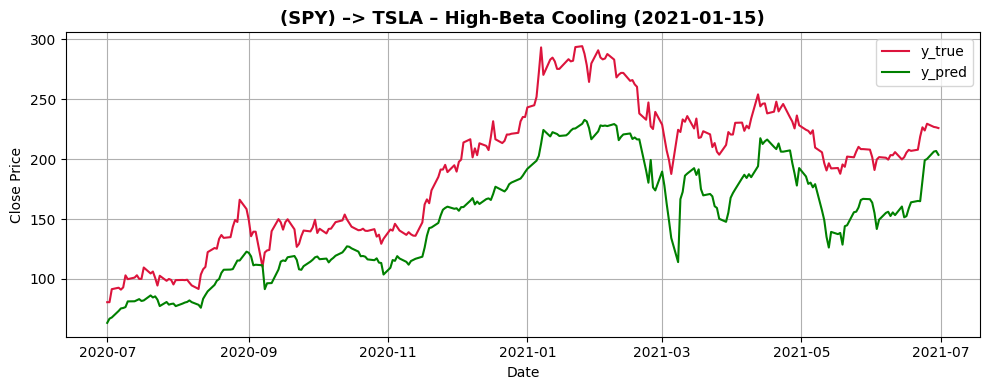

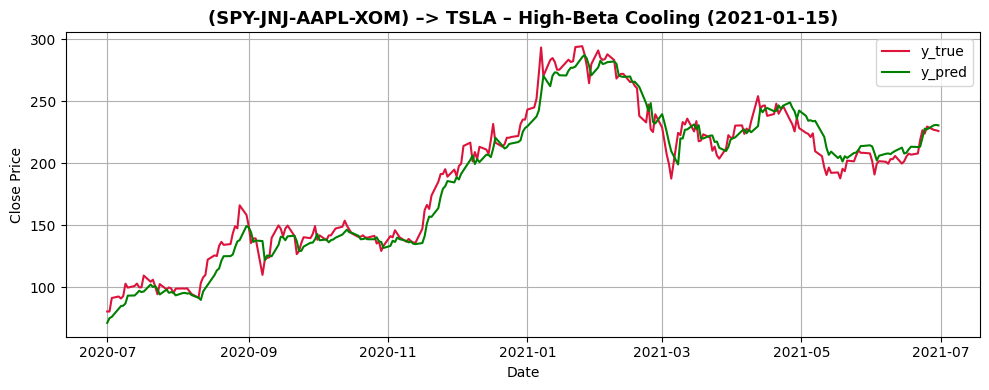

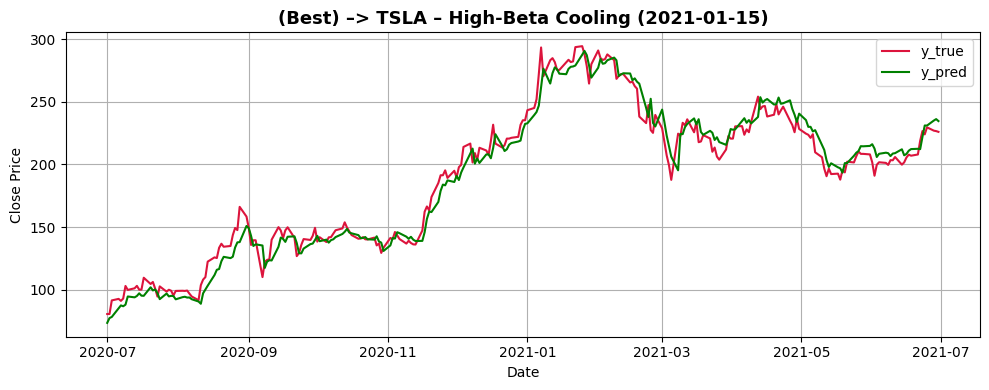

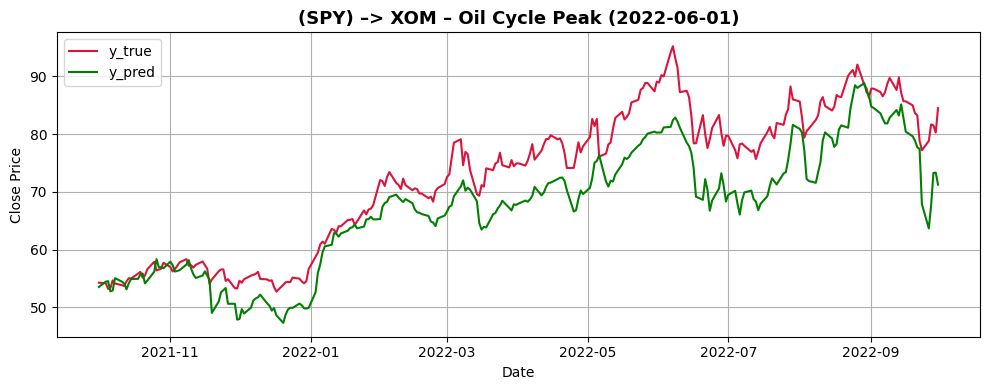

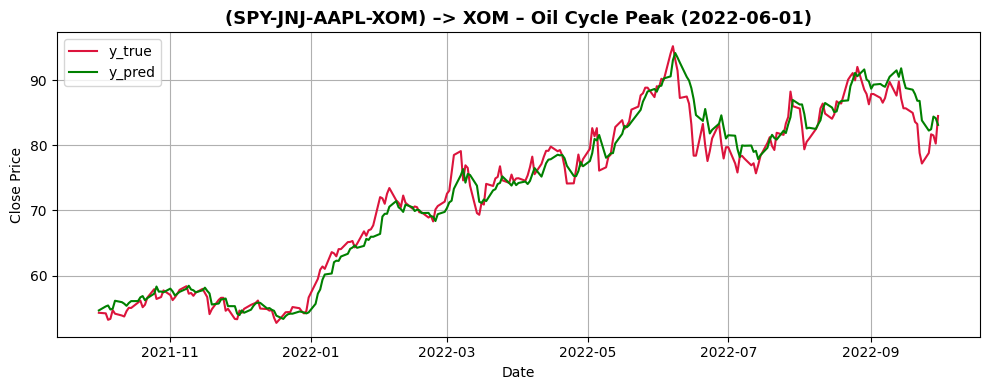

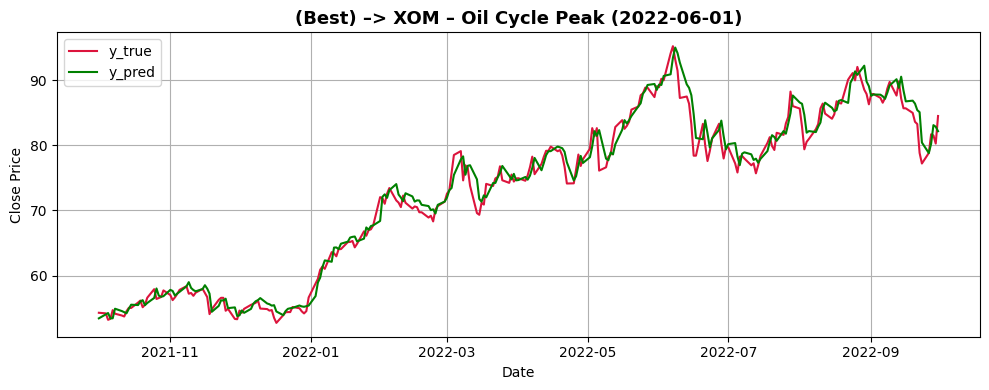

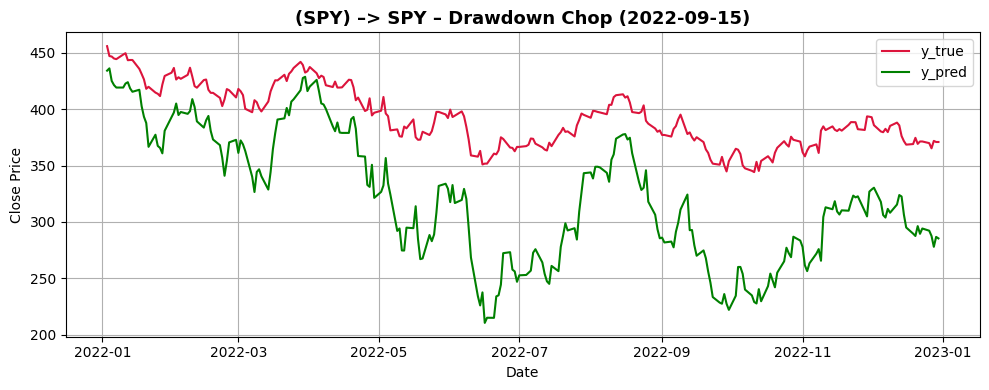

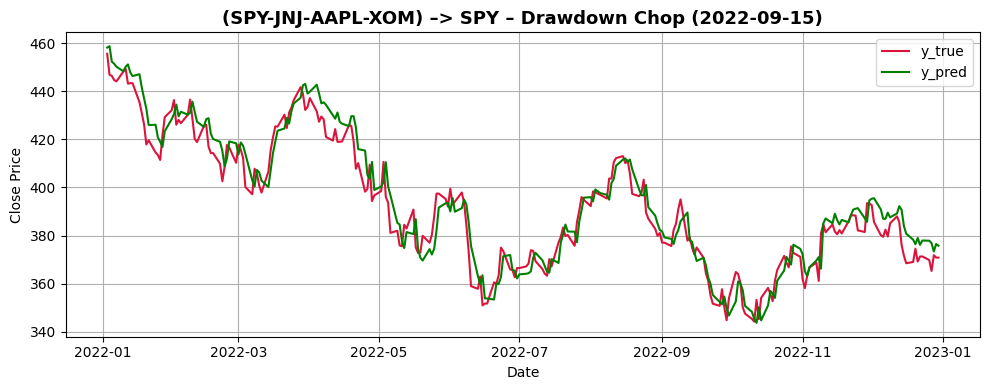

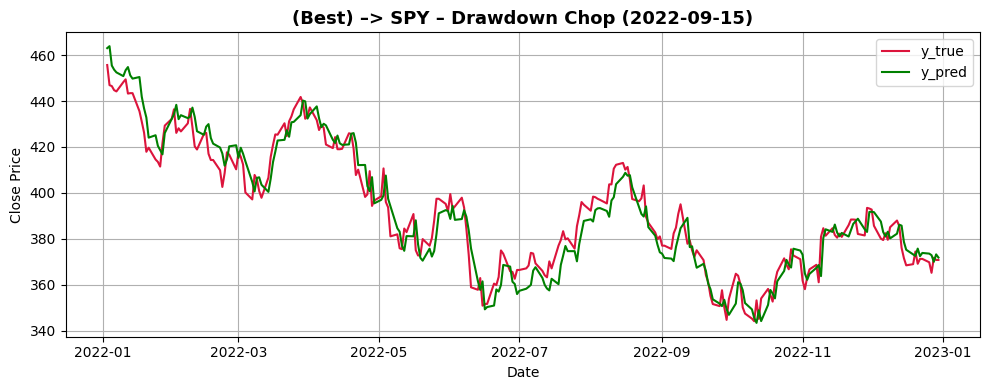

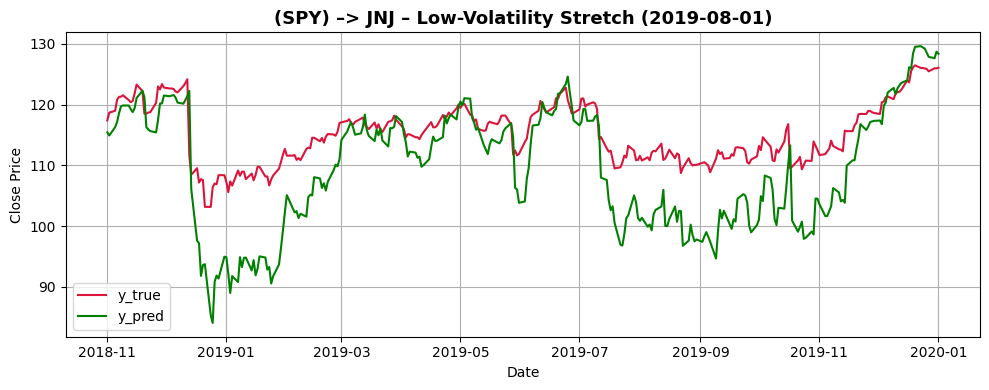

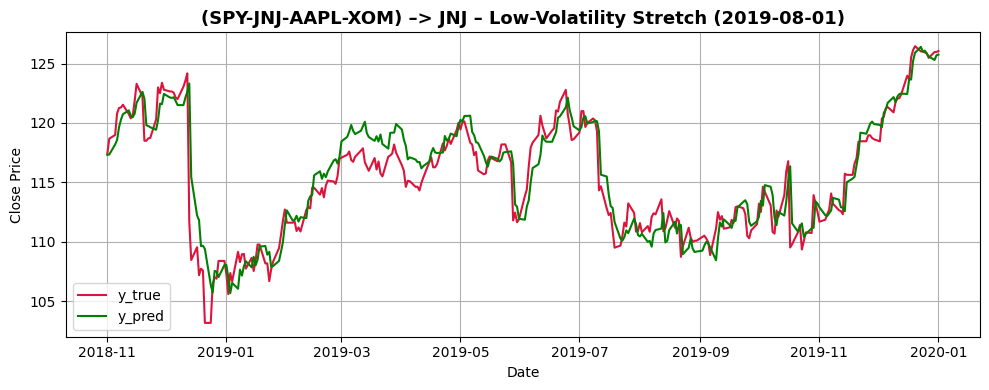

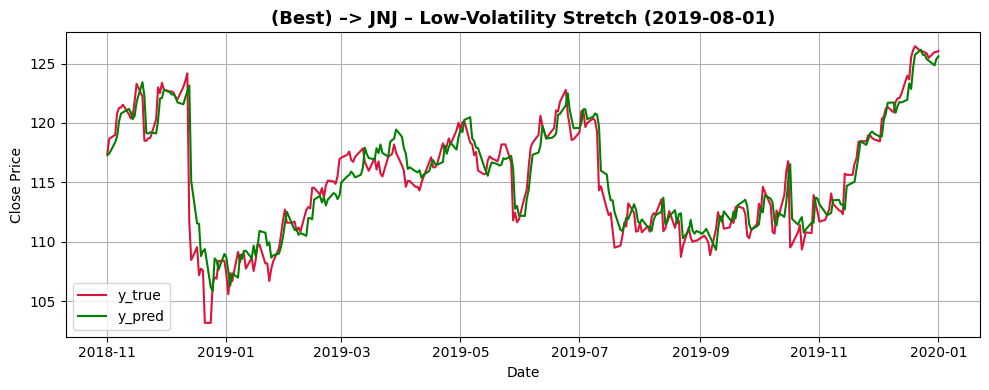

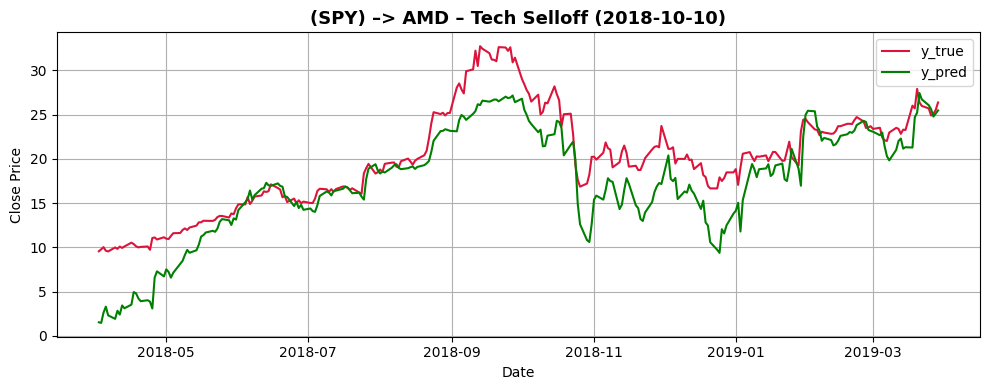

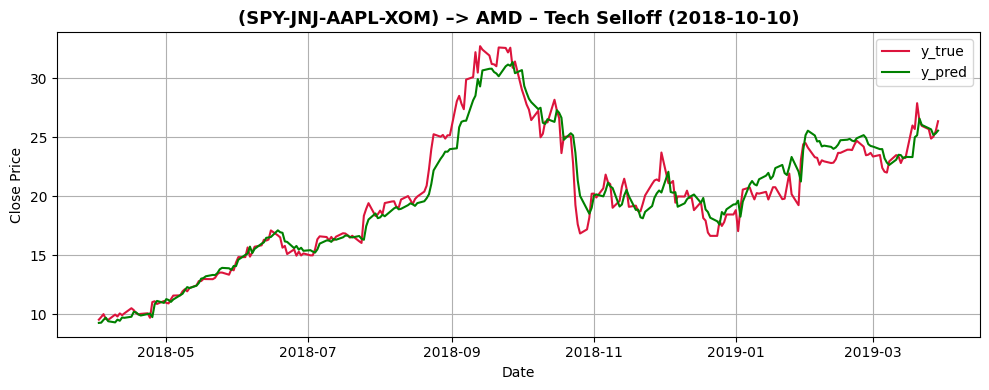

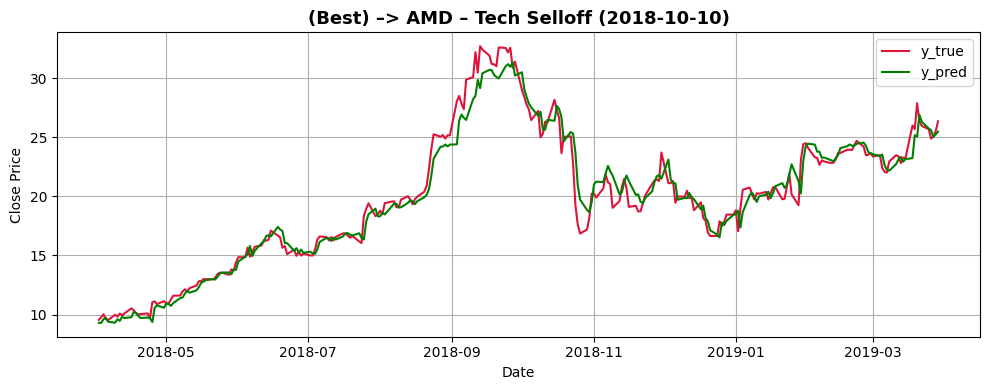

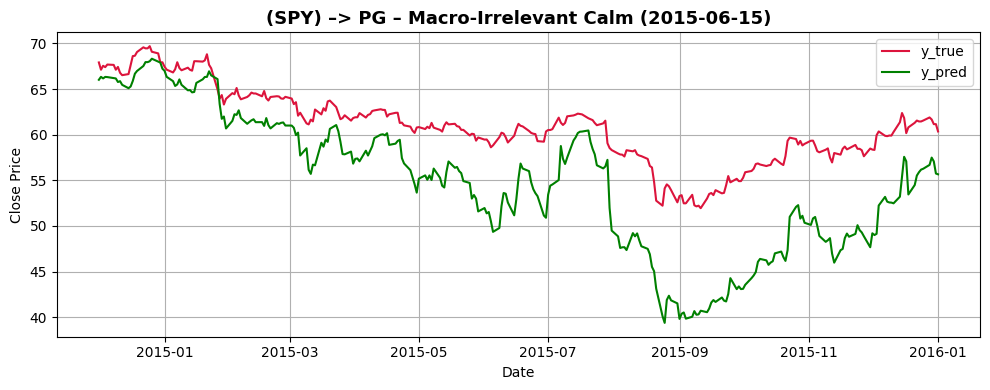

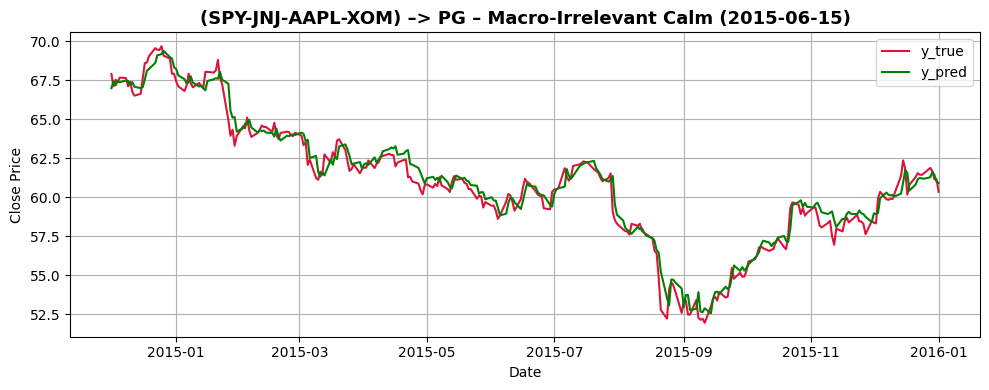

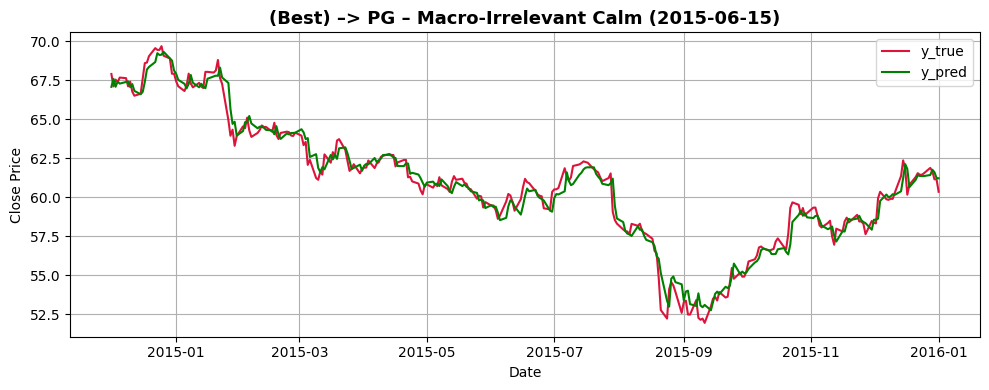

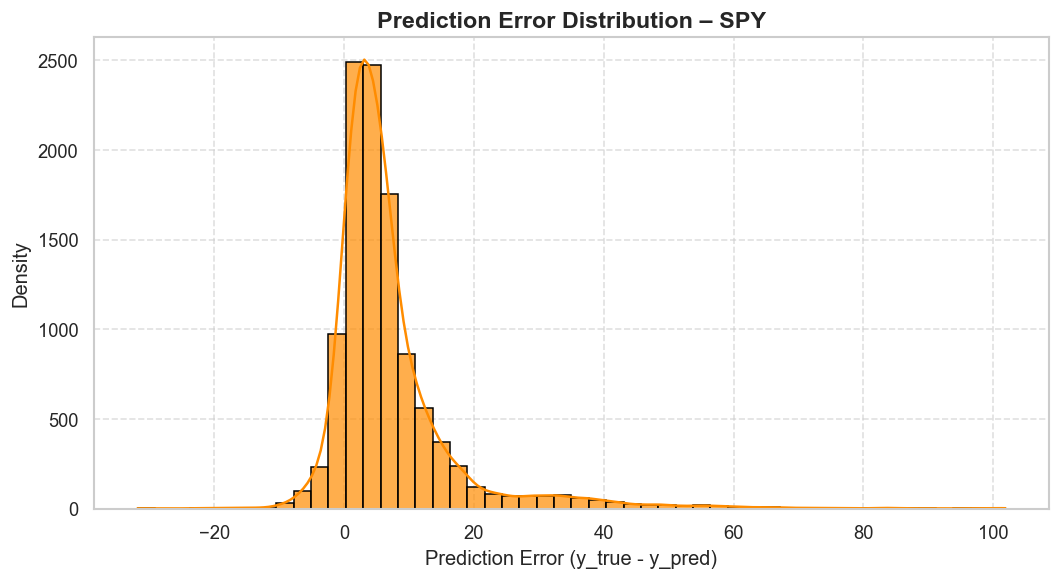

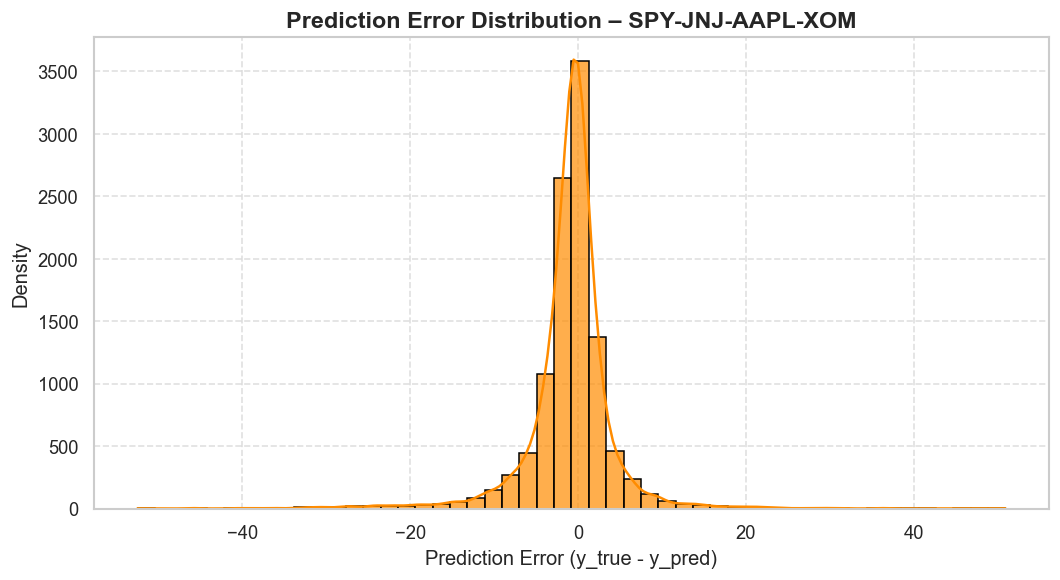

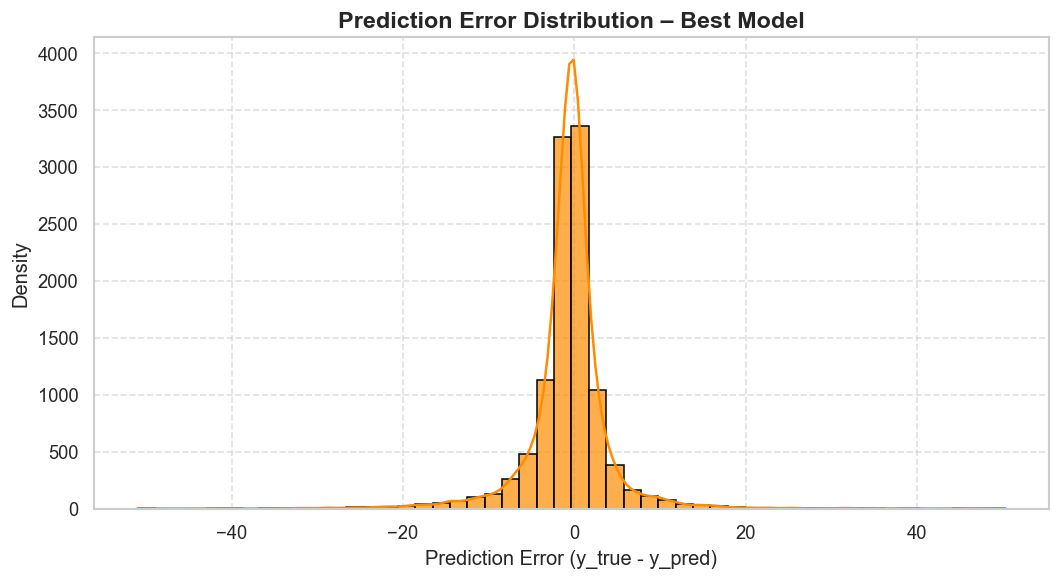

  ticker        mae       rmse       mape  hit_rate  precision    recall  \
0   AAPL   4.492060   5.913104   3.654361  0.476008   0.511945  0.550796   
1   TSLA  18.232563  24.579306  10.374491  0.492399   0.515700  0.551680   
2    XOM   2.643769   3.332902   4.650494  0.488804   0.493812  0.520888   
3    SPY   2.935147   3.863040   2.315037  0.476008   0.511468  0.545900   
4    JNJ   2.412834   3.100648   1.717041  0.502239   0.516169  0.536176   
5    AMD   6.408386   8.753954   7.013585  0.471529   0.471515  0.513871   
6     PG   2.436160   3.092036   1.953492  0.467051   0.501738  0.528694   

         f1  
0  0.530660  
1  0.533084  
2  0.506989  
3  0.528123  
4  0.525982  
5  0.491783  
6  0.514863  
  ticker       mae       rmse      mape  hit_rate  precision    recall  \
0   AAPL  2.248417   3.040631  1.748386  0.463666   0.502320  0.532595   
1   TSLA  8.068379  11.743524  4.781363  0.481063   0.508055  0.531777   
2    XOM  1.572729   2.071868  2.887703  0.480386   0.489

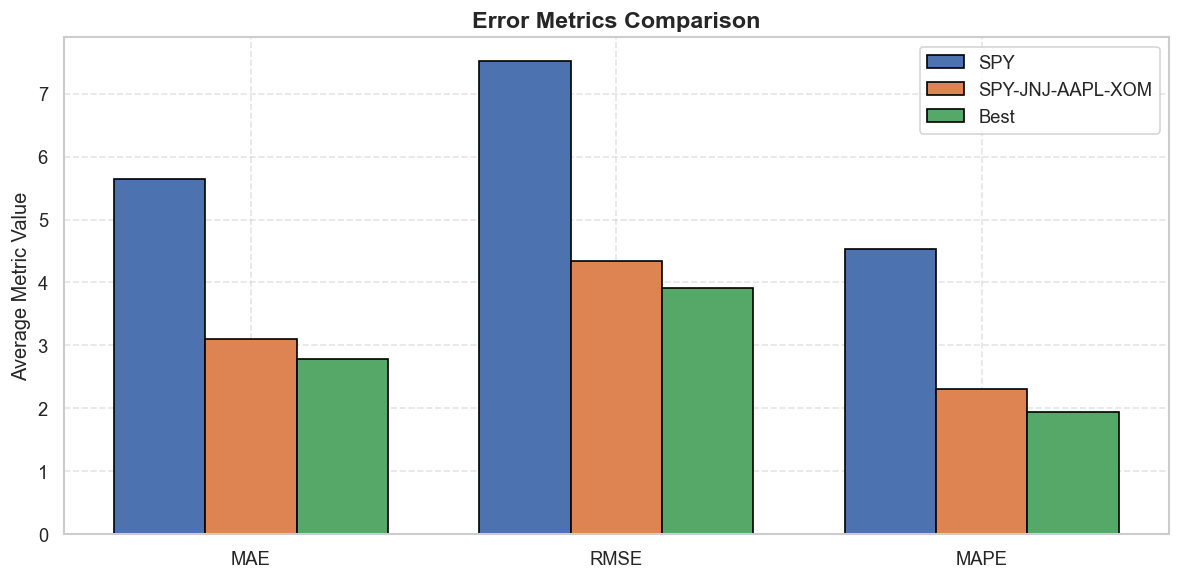

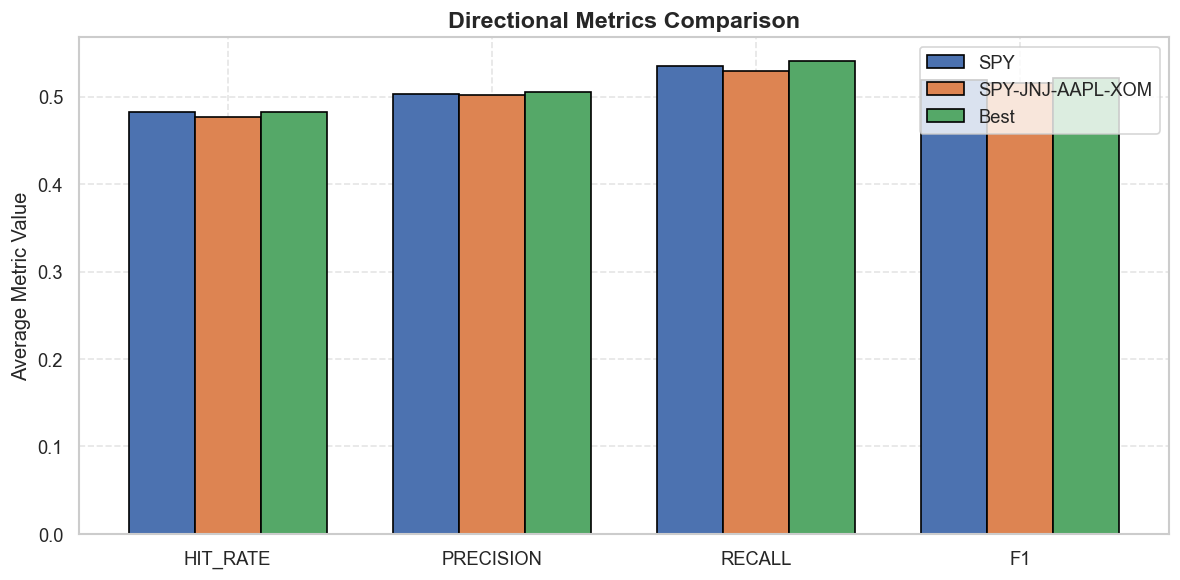

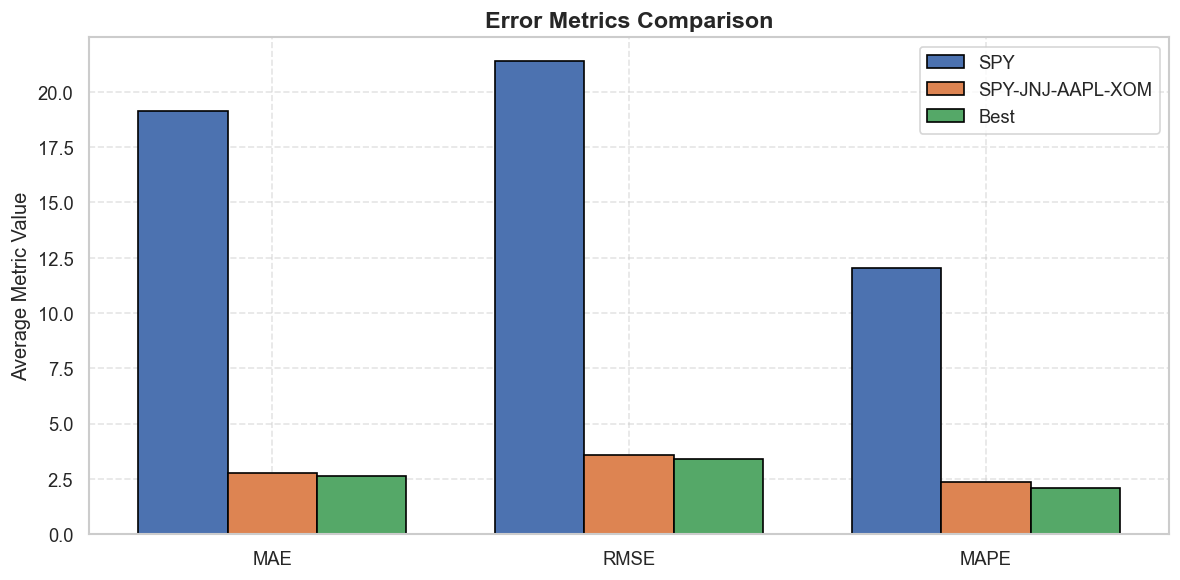

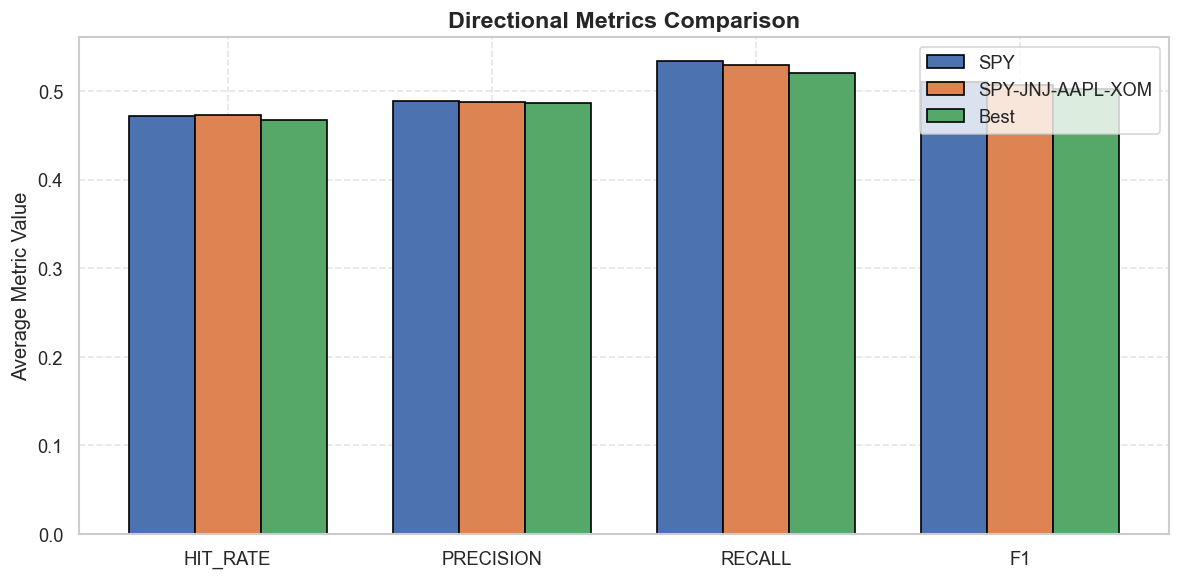

                           mae       rmse      mape  hit_rate  precision  \
regime_type                                                                
High-Volatility      12.320475  16.666630  8.694038  0.481964   0.493608   
Low-Volatility        2.424497   3.096342  1.835266  0.484645   0.508954   
Post-Trend Reversal   3.567915   4.623003  4.152428  0.482406   0.502879   
Sideways/Chop         2.935147   3.863040  2.315037  0.476008   0.511468   

                       recall        f1  
regime_type                              
High-Volatility      0.532775  0.512433  
Low-Volatility       0.532435  0.520423  
Post-Trend Reversal  0.535842  0.518824  
Sideways/Chop        0.545900  0.528123  
                          mae      rmse      mape  hit_rate  precision  \
regime_type                                                              
High-Volatility      5.616002  8.119181  4.138039  0.475017   0.488044   
Low-Volatility       1.438497  1.925030  1.081021  0.481445   0.50866

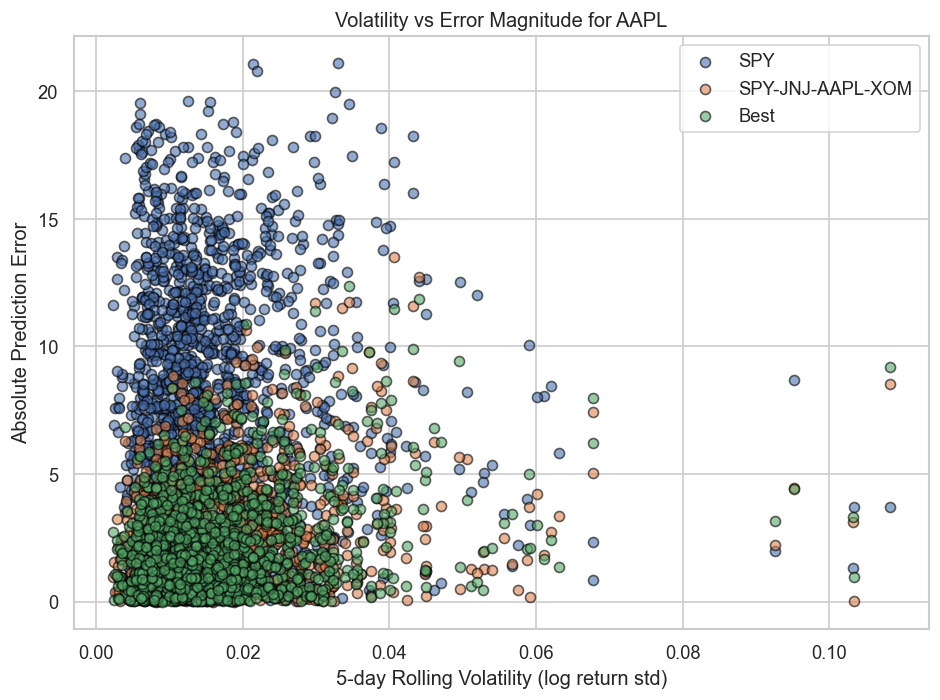

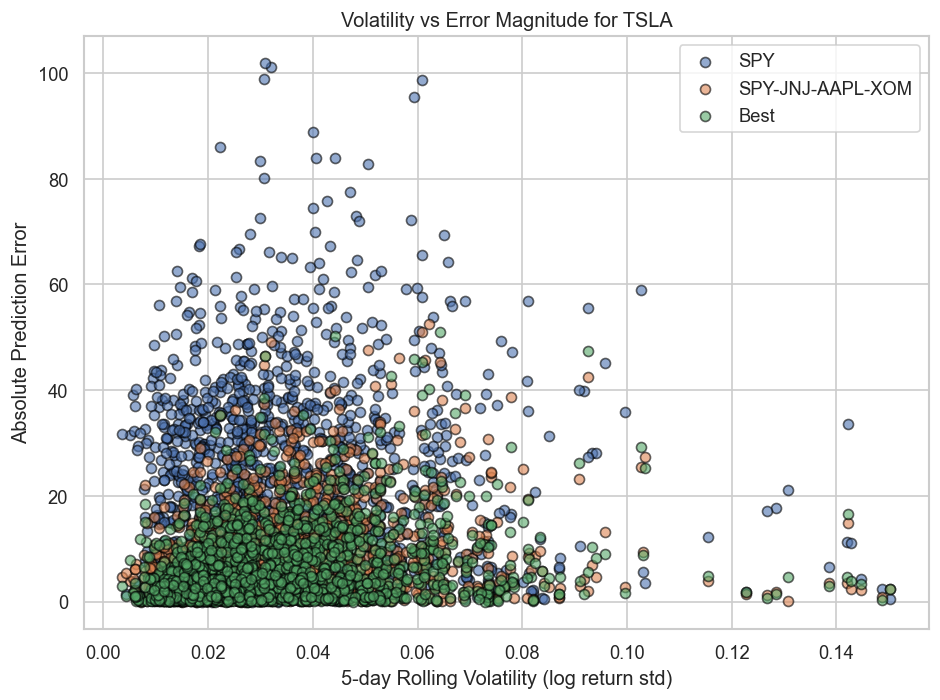

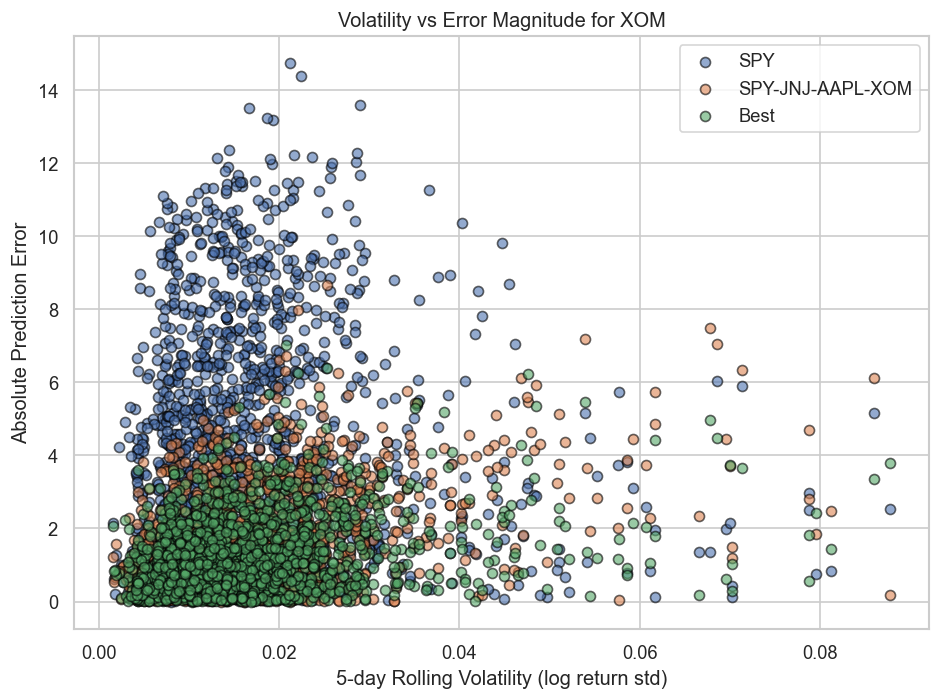

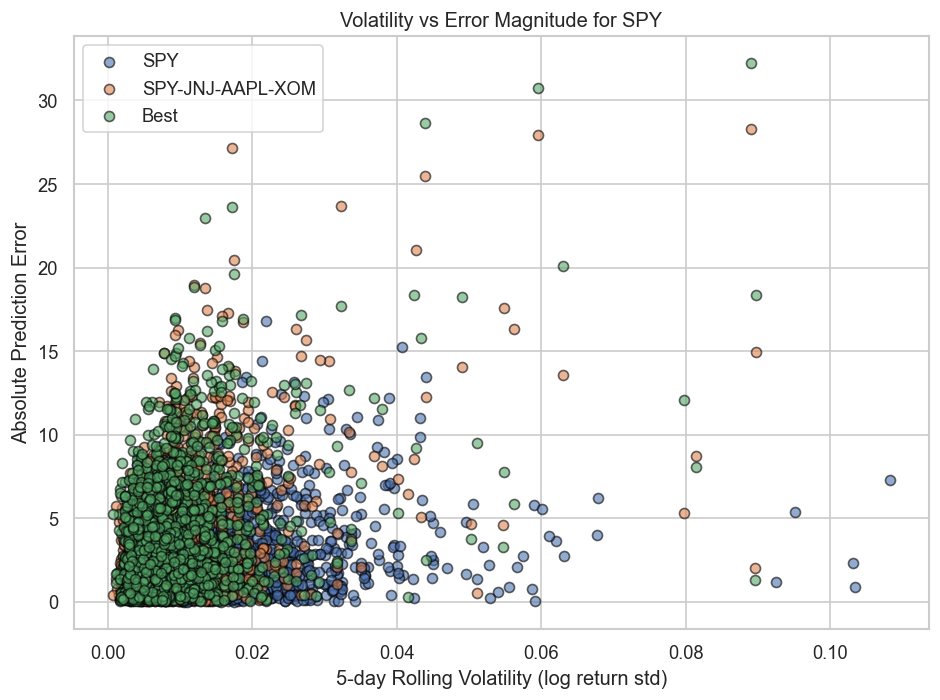

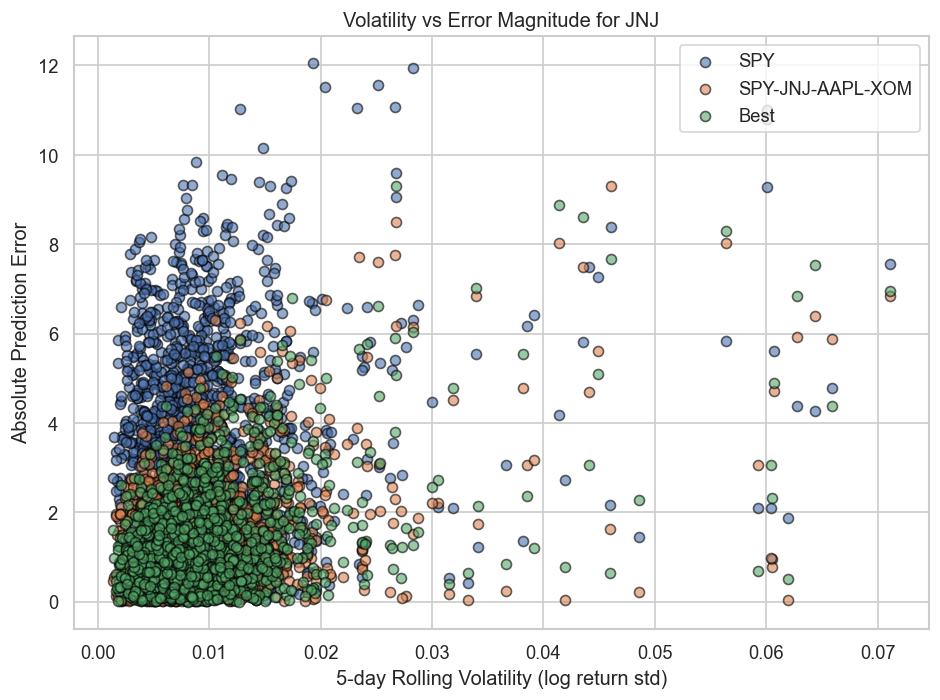

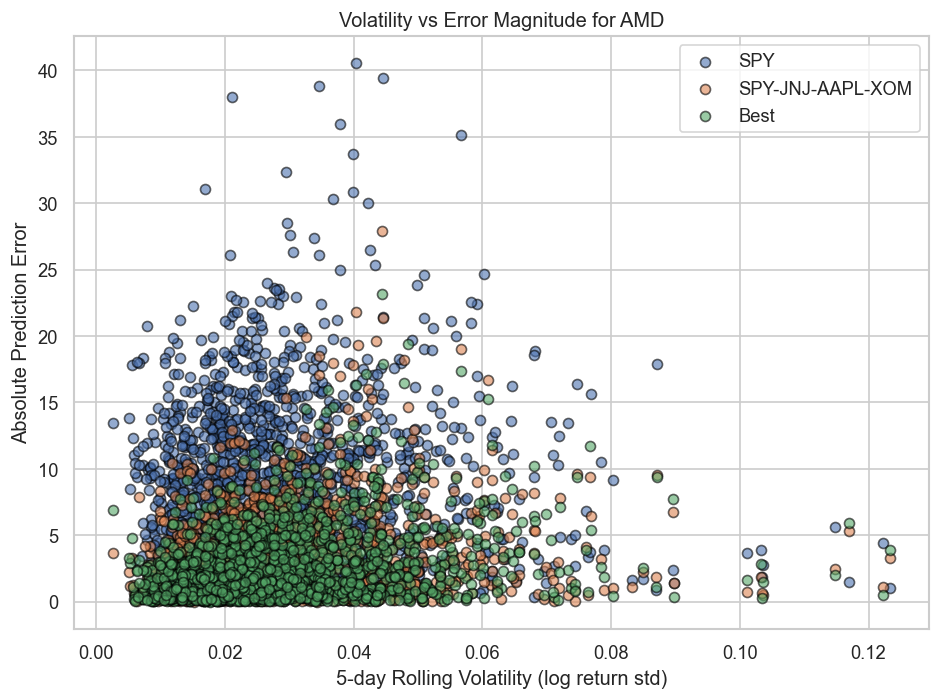

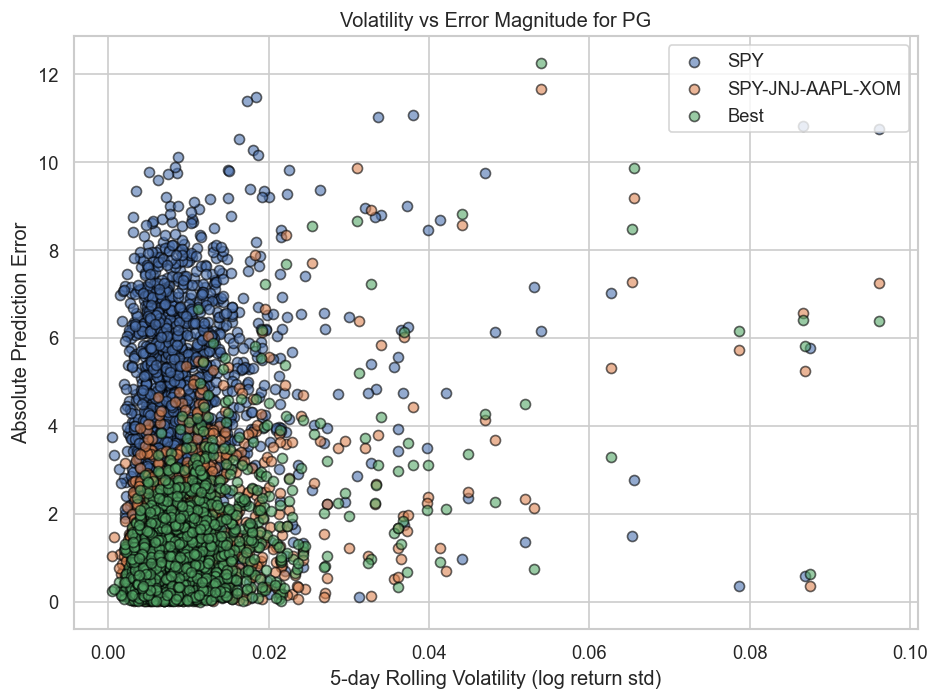

AAPL: -0.0492
TSLA: 0.0400
XOM: 0.0166
SPY: 0.1120
JNJ: 0.0907
AMD: -0.0086
PG: 0.0565
AAPL: 0.2397
TSLA: 0.1899
XOM: 0.4297
SPY: 0.4139
JNJ: 0.3892
AMD: 0.1640
PG: 0.3911
AAPL: 0.2680
TSLA: 0.2079
XOM: 0.2774
SPY: 0.3834
JNJ: 0.4484
AMD: 0.2507
PG: 0.4754


In [1]:
import math
import os
import torch
import time
import ast
import joblib
import warnings
import random
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import precision_score, recall_score, f1_score

warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

# Create save directory
os.makedirs("eval_results", exist_ok=True)

tickers = ["AAPL", "TSLA", "XOM", "SPY", "JNJ", "AMD", "PG"]

event_titles = [
    "AAPL – Crash & Rebound (2020-03-10)",
    "TSLA – High-Beta Cooling (2021-01-15)",
    "XOM – Oil Cycle Peak (2022-06-01)",
    "SPY – Drawdown Chop (2022-09-15)",
    "JNJ – Low-Volatility Stretch (2019-08-01)",
    "AMD – Tech Selloff (2018-10-10)",
    "PG – Macro-Irrelevant Calm (2015-06-15)"
]

starts = ["2019-09-02", "2020-07-01", "2021-10-01", "2022-01-03", "2018-11-01", "2018-04-02", "2014-12-01"]
ends   = ["2020-06-01", "2021-06-30", "2022-09-30", "2022-12-30", "2020-01-01", "2019-03-29", "2016-01-01"]

regime_map = {
    "TSLA": "High-Volatility",
    "AMD": "High-Volatility",
    "SPY": "Sideways/Chop",
    "PG": "Low-Volatility",
    "JNJ": "Low-Volatility",
    "AAPL": "Post-Trend Reversal",
    "XOM": "Post-Trend Reversal"
}

metrics_to_plot = ["mae", "rmse", "mape", "hit_rate", "precision", "recall", "f1"]

path_templates = [
    './spy/finetune_on_SPY_predict_{ticker}.csv',
    './fewshot_full_results/{ticker}_full_results.csv',
    './finalmodel/{ticker}_final_results.csv',
]

event_templates = [
    './spy/finetune_on_SPY_predict_{ticker}_event.csv',
    './fewshot_full_results/{ticker}_full_event_results.csv',
    './finalmodel/{ticker}_final_event_results.csv'
]

model_labels = ['SPY', 'SPY-JNJ-AAPL-XOM', 'Best']


def liplot(forecast, title, filename):
    plt.figure(figsize=(10, 4))
    plt.plot(forecast["date"], forecast["y_true"], label="y_true", color='crimson')
    plt.plot(forecast["date"], forecast["y_pred"], label="y_pred", color='green')
    plt.title(title, fontsize=13, weight='bold')
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"eval_results/{filename}.png", dpi=300, bbox_inches='tight')
    plt.show()


def plot_compare(templates, model_labels, is_event=False):
    for ticker, start, end, event_title in zip(tickers, starts, ends, event_titles):
        for i in range(3):
            path = templates[i].format(ticker=ticker)
            forecast = pd.read_csv(path)
            forecast["date"] = pd.to_datetime(forecast["date"])

            if is_event:
                title = f"({model_labels[i]}) –> {event_title}"
                filename = f"{model_labels[i]}_{ticker}_event"
            else:
                title = f"({model_labels[i]}) –> {ticker} – test set"
                filename = f"{model_labels[i]}_{ticker}_test"

            liplot(forecast, title, filename)


def error_plots(template, label="Model"):
    all_errors = []

    for ticker in tickers:
        path = template.format(ticker=ticker)
        df = pd.read_csv(path)
        errors = df['y_true'] - df['y_pred']
        errors = errors.dropna()
        all_errors.extend(errors.values)

    plt.figure(figsize=(9, 5), dpi=120)
    sns.set(style="whitegrid")
    sns.histplot(all_errors, bins=50, kde=True, color="darkorange", edgecolor='black', alpha=0.7)
    plt.title(f"Prediction Error Distribution – {label}", fontsize=14, weight='bold')
    plt.xlabel("Prediction Error (y_true - y_pred)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"eval_results/error_dist_{label.replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.show()


def plot_grouped_metrics(df):
    group1 = ["mae", "rmse", "mape"]
    group2 = ["hit_rate", "precision", "recall", "f1"]
    sns.set_style("whitegrid")
    colors1 = sns.color_palette("Set2", len(group1))
    colors2 = sns.color_palette("Set2", len(group2))

    def plot_bar_group(metrics, colors, title_suffix, filename):
        tickers = df.index.tolist()
        x = np.arange(len(tickers))
        width = 0.15

        fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
        for i, metric in enumerate(metrics):
            ax.bar(x + i * width, df[metric], width, label=metric.upper(), color=colors[i], edgecolor="black")

        ax.set_title(f"{title_suffix} per Ticker", fontsize=14, weight='bold')
        ax.set_xlabel("Ticker", fontsize=12)
        ax.set_ylabel("Metric Value", fontsize=12)
        ax.set_xticks(x + width * (len(metrics) - 1) / 2)
        ax.set_xticklabels(tickers, rotation=45)
        ax.legend()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig(f"eval_results/{filename}.png", dpi=300, bbox_inches='tight')
        plt.show()

    plot_bar_group(group1, colors1, "Error Metrics", "group1_error_metrics")
    plot_bar_group(group2, colors2, "Directional Metrics", "group2_classification_metrics")


def regime_matrix(df):
    df.set_index("ticker", inplace=True)
    df['regime_type'] = df.index.map(regime_map)
    grouped_df = df.groupby('regime_type').mean(numeric_only=True)
    grouped_df.to_csv("eval_results/regime_matrix.csv")
    print(grouped_df)


def roll_vol(path_templates):
    for ticker in tickers:
        plt.figure(figsize=(8, 6), dpi=120)
        for template, label in zip(path_templates, model_labels):
            path = template.format(ticker=ticker)
            df = pd.read_csv(path)
            df['log_return'] = np.log(df['y_true']).diff()
            df['rolling_volatility'] = df['log_return'].rolling(window=5).std()
            df['abs_error'] = np.abs(df['y_true'] - df['y_pred'])
            df_clean = df.dropna(subset=['rolling_volatility', 'abs_error'])

            plt.scatter(df_clean['rolling_volatility'], df_clean['abs_error'],
                        alpha=0.6, label=label, edgecolor='black')
        plt.title(f"Volatility vs Error Magnitude for {ticker}")
        plt.xlabel("5-day Rolling Volatility (log return std)")
        plt.ylabel("Absolute Prediction Error")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"eval_results/{ticker}_combined_rolling_volatility.png", dpi=300, bbox_inches='tight')
        plt.show()


def pearson_cor(path_template, label):
    pear = []
    for ticker in tickers:
        path = path_template.format(ticker=ticker)
        df = pd.read_csv(path)
        df['log_return'] = np.log(df['y_true']).diff()
        df['rolling_volatility'] = df['log_return'].rolling(window=5).std()
        df['abs_error'] = np.abs(df['y_true'] - df['y_pred'])
        df_clean = df.dropna(subset=['rolling_volatility', 'abs_error'])
        corr, pval = pearsonr(df_clean['rolling_volatility'], df_clean['abs_error'])
        pear.append(corr)

    filename = f"eval_results/pearson_correlations_{label.replace(' ', '_')}.txt"
    with open(filename, "w") as f:
        f.write(f"Pearson Correlation (Volatility vs Error) – {label}\n\n")
        for ticker, corr in zip(tickers, pear):
            line = f"{ticker}: {corr:.4f}"
            print(line)
            f.write(line + "\n")


def plot_combined_grouped_metrics(dfs, model_labels, group_metrics, title):
    sns.set_style("whitegrid")
    data = [df[group_metrics].mean().values for df in dfs]
    data = np.array(data)
    num_models = len(model_labels)
    num_metrics = len(group_metrics)

    x = np.arange(num_metrics)
    width = 0.25

    plt.figure(figsize=(10, 5), dpi=120)
    for i in range(num_models):
        plt.bar(x + i * width, data[i], width, label=model_labels[i], edgecolor='black')

    plt.xticks(x + width * (num_models - 1) / 2, [m.upper() for m in group_metrics])
    plt.ylabel("Average Metric Value")
    plt.title(title, fontsize=14, weight='bold')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"eval_results/{title.replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.show()


# Load data
df1 = pd.read_csv('spy/finetune_on_SPY.csv')
df2 = pd.read_csv('fewshot_results/df2.csv')
df3 = pd.read_csv('finalmodel/output.csv')
ev1 = pd.read_csv('spy/finetune_on_SPY_event.csv')
ev2 = pd.read_csv('fewshot_results/finetune_all_event.csv')
ev3 = pd.read_csv('finalmodel/event_output.csv')

# Save data
df1.to_csv("eval_results/df1.csv", index=False)
df2.to_csv("eval_results/df2.csv", index=False)
df3.to_csv("eval_results/df3.csv", index=False)
ev1.to_csv("eval_results/ev1.csv", index=False)
ev2.to_csv("eval_results/ev2.csv", index=False)
ev3.to_csv("eval_results/ev3.csv", index=False)

# Plot functions
plot_compare(path_templates, model_labels, is_event=False)
plot_compare(event_templates, model_labels, is_event=True)
error_plots(path_templates[0], label="SPY")
error_plots(path_templates[1], label="SPY-JNJ-AAPL-XOM")
error_plots(path_templates[2], label="Best Model")

print(df1)
print(df2)
print(df3)
print(ev1)
print(ev2)
print(ev3)

dfs = [df1, df2, df3]
plot_combined_grouped_metrics(dfs, model_labels, group_metrics=["mae", "rmse", "mape"], title="Error Metrics Comparison")
plot_combined_grouped_metrics(dfs, model_labels, group_metrics=["hit_rate", "precision", "recall", "f1"], title="Directional Metrics Comparison")

evs = [ev1, ev2, ev3]
plot_combined_grouped_metrics(evs, model_labels, group_metrics=["mae", "rmse", "mape"], title="Error Metrics Comparison")
plot_combined_grouped_metrics(evs, model_labels, group_metrics=["hit_rate", "precision", "recall", "f1"], title="Directional Metrics Comparison")


regime_matrix(df1)
regime_matrix(df2)
regime_matrix(df3)
roll_vol(path_templates)
pearson_cor(path_templates[0], label="SPY")
pearson_cor(path_templates[1], label="SPY-JNJ-AAPL-XOM")
pearson_cor(path_templates[2], label="Best Model")


In [2]:
def build_comparison_df(metric, dfs, model_labels):
    rows = []
    for ticker in tickers:
        row = {'ticker': ticker}
        for df, label in zip(dfs, model_labels):
            row[label] = df.loc[ticker, metric]
        rows.append(row)
    return pd.DataFrame(rows).set_index("ticker")

def add_deltas(df, baseline="SPY"):
    for col in df.columns:
        if col != baseline:
            df[f"{col} - {baseline}"] = df[col] - df[baseline]
    return df


def plot_delta_bar(df, model_label, baseline="SPY", metric="rmse"):
    delta_col = f"{model_label} - {baseline}"
    df_sorted = df.sort_values(delta_col, ascending=True)

    plt.figure(figsize=(10, 5), dpi=120)
    df_sorted[delta_col].plot(kind="barh", color='seagreen', edgecolor='black')
    plt.axvline(0, color="gray", linestyle="--")
    plt.title(f"{model_label} vs {baseline} – Δ {metric.upper()}")
    plt.xlabel(f"Δ {metric.upper()} ({model_label} - {baseline})")
    plt.ylabel("Target Ticker")
    plt.tight_layout()
    plt.savefig("f1.png", dpi=300, bbox_inches='tight')
    plt.show()

    
def plot_heatmap(df, model_labels, metric="rmse"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(df[model_labels], annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title(f"Model Comparison – {metric.upper()}")
    plt.tight_layout()
    plt.show()


metric = "f1"
model_labels = ['SPY', 'SPY-JNJ-AAPL-XOM', 'Best','zeroshot']
dfs = [df1, df2, df3,df4]

comp_df = build_comparison_df(metric, dfs, model_labels)
comp_df = add_deltas(comp_df, baseline="SPY")

plot_delta_bar(comp_df, model_label="SPY-JNJ-AAPL-XOM", baseline="SPY", metric=metric)
plot_heatmap(comp_df, model_labels, metric=metric)

NameError: name 'df4' is not defined

          Sharpe  cum_return  max_drawdown
ticker                                    
AAPL    0.222830    0.511878      0.493894
TSLA    0.255188    1.640714      0.664336
XOM     0.397650    1.178139      0.402989
SPY     0.431494    0.682979      0.365788
JNJ     0.336500    0.476909      0.364576
AMD    -0.225300   -0.509738      0.829657
PG      0.190841    0.264420      0.357608


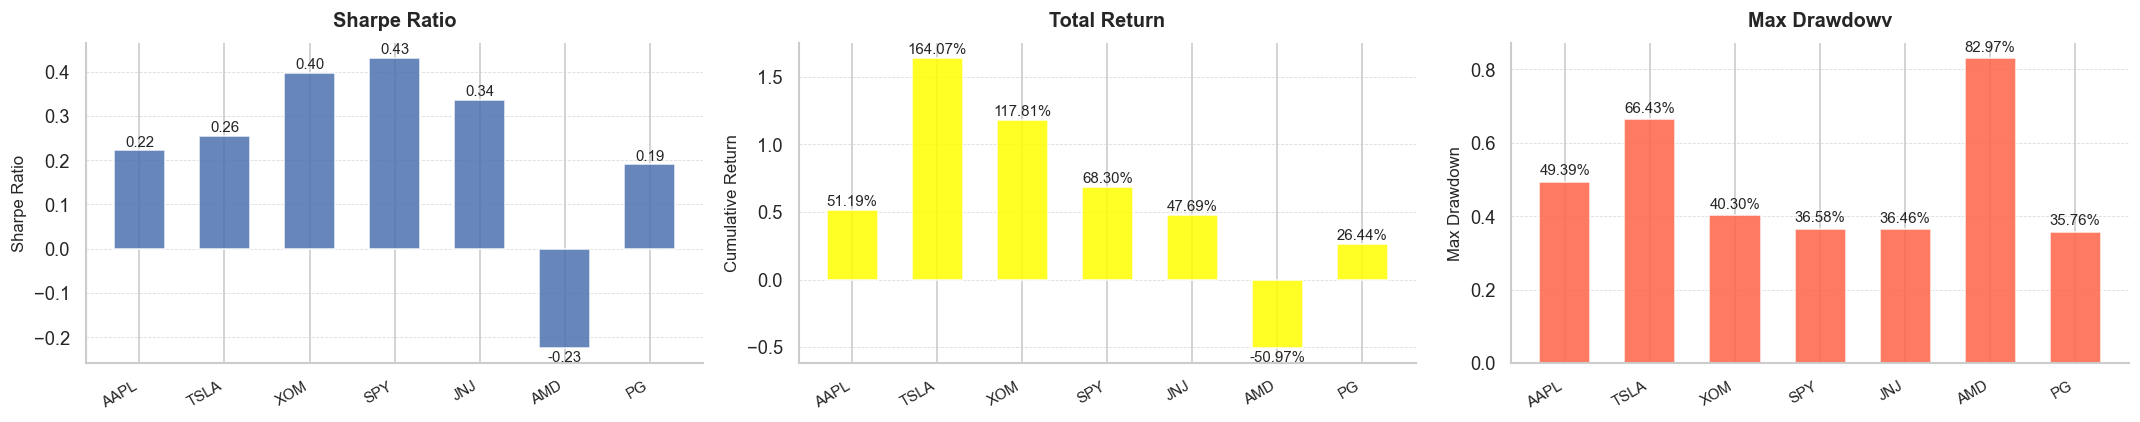

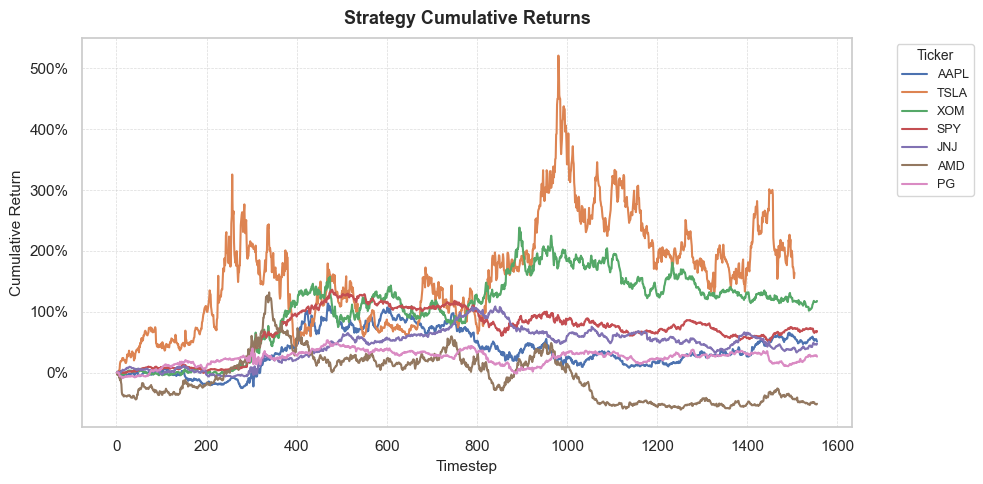

KeyError: "None of ['ticker'] are in the columns"

In [5]:
import math
import os
import torch
import time
import ast
import joblib
import warnings
import torch
import random
import seaborn as sns
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import wilcoxon
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

os.makedirs("best_results", exist_ok=True)

def econ_metrics(df, trading_days=252):
    df = df.copy()
    # log-returns
    df["log_return"] = np.log(df["y_true"]).diff()
    df["pred_log_return"] = np.log(df["y_pred"]).diff()

    # position from prediction (shifted για να αποφύγουμε look-ahead)
    df["position"] = np.sign(df["pred_log_return"]).shift(1).fillna(0.0)

    # daily strategy log-return
    df["strat_log_ret"] = df["position"] * df["log_return"]

    # equity curve από log-returns
    df["equity"] = np.exp(df["strat_log_ret"].cumsum())

    # annualized sharpe (risk-free ~0)
    mu = df["strat_log_ret"].mean()
    sd = df["strat_log_ret"].std()
    sharpe = np.nan if sd == 0 or np.isnan(sd) else (mu / sd) * np.sqrt(trading_days)

    # συνολική απόδοση (equity_t - 1)
    cum_return = df["equity"].iloc[-1] - 1

    # max drawdown στο equity
    rolling_max = df["equity"].cummax()
    drawdown = (rolling_max - df["equity"]) / rolling_max
    max_drawdown = drawdown.max()

    return {
        "Sharpe": sharpe,
        "cum_return": cum_return,
        "max_drawdown": max_drawdown,
        "cum_series": df["equity"] - 1.0  # για plotting σε ποσοστό
    }

tickers = ["AAPL", "TSLA", "XOM", "SPY", "JNJ", "AMD", "PG"]
tmplt = './finalmodel/{ticker}_final_results.csv'

econ = []
series = {}

for ticker in tickers:
    df = pd.read_csv(tmplt.format(ticker=ticker))
    df = df.dropna(subset=['y_true', 'y_pred'])
    em = econ_metrics(df)
    em["ticker"] = ticker
    econ.append(em)
    series[ticker] = em["cum_series"]

econ_df = pd.DataFrame(econ).set_index("ticker")
econ_df = econ_df.drop(columns=["cum_series"])
econ_df.to_csv("eval_results/econ_metrics.csv")
print(econ_df)

x = np.arange(len(tickers))
width = 0.6

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4), dpi=120, sharey=False)

bars_sh = ax1.bar(x, econ_df["Sharpe"], width, label="Sharpe Ratio", alpha=0.85)
for rect in bars_sh:
    h = rect.get_height()
    if np.isnan(h): continue
    ax1.text(rect.get_x() + rect.get_width()/2, h + (0.002 if h >= 0 else -0.004),
             f"{h:.2f}", ha="center", va="bottom" if h >= 0 else "top", fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(tickers, rotation=30, ha="right", fontsize=9)
ax1.set_title("Sharpe Ratio", fontsize=12, weight="bold", pad=10)
ax1.set_ylabel("Sharpe Ratio", fontsize=10)
ax1.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
for spine in ["top", "right"]: ax1.spines[spine].set_visible(False)

bars_cr = ax2.bar(x, econ_df["cum_return"], width, label="Cumulative Return", alpha=0.85,  color='yellow')
for rect in bars_cr:
    h = rect.get_height()
    if np.isnan(h): continue
    ax2.text(rect.get_x() + rect.get_width()/2, h + (0.01 if h >= 0 else -0.02),
             f"{h:.2%}", ha="center", va="bottom" if h >= 0 else "top", fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(tickers, rotation=30, ha="right", fontsize=9)
ax2.set_title("Total Return", fontsize=12, weight="bold", pad=10)
ax2.set_ylabel("Cumulative Return", fontsize=10)
ax2.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
for spine in ["top", "right"]: ax2.spines[spine].set_visible(False)

bars_md = ax3.bar(x, econ_df["max_drawdown"], width, label="Max Drawdown", alpha=0.85, color='tomato')
for rect in bars_md:
    h = rect.get_height()
    if np.isnan(h): continue
    ax3.text(rect.get_x() + rect.get_width()/2, h + 0.01,
             f"{h:.2%}", ha="center", va="bottom", fontsize=9)
ax3.set_xticks(x)
ax3.set_xticklabels(tickers, rotation=30, ha="right", fontsize=9)
ax3.set_title("Max Drawdowν", fontsize=12, weight="bold", pad=10)
ax3.set_ylabel("Max Drawdown", fontsize=10)
ax3.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
for spine in ["top", "right"]: ax3.spines[spine].set_visible(False)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("eval_results/econ_barplots.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
for sym, cum in series.items():
    plt.plot(cum.index, cum.values, label=sym)

plt.title("Strategy Cumulative Returns", fontsize=13, weight="bold", pad=10)
plt.xlabel("Timestep", fontsize=11)
plt.ylabel("Cumulative Return", fontsize=11)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(title="Ticker", fontsize=9, title_fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("eval_results/strategy_cumulative_returns.png", dpi=300, bbox_inches='tight')
plt.show()

def wilc(df_best, df_base, label=""):
    df_base = df_base.set_index("ticker")
    df_best = df_best.set_index("ticker")
    common = df_base.index.intersection(df_best.index)

    metrics = ["mae","rmse","mape","hit_rate","precision","recall","f1"]
    pvals, imp = {}, {}

    with open(f"eval_results/wilcoxon_{label.lower()}.txt", "w") as f:
        f.write(f"Wilcoxon p-values ({label}):\n")
        for m in metrics:
            # δύο-δειγματικός Wilcoxon σε ζεύγη ticker
            stat, p = wilcoxon(df_base.loc[common, m], df_best.loc[common, m])
            pvals[m] = p
            star = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
            f.write(f"{m}: {p:.6f} {star}\n")

    # πίνακας βελτίωσης (%)
    err_base = df_base.loc[common, ["mae","rmse","mape"]]
    err_best = df_best.loc[common, ["mae","rmse","mape"]]
    diff = (err_base - err_best)
    diff_pct = diff / err_base.replace(0, np.nan)
    diff_pct.to_csv(f"eval_results/error_improvement_{label.lower()}.csv")

df4 = pd.read_csv('baseline_results/baseline_output.csv')
wilc(df3, df4, label="Τest")

common_idx = df4.index.intersection(df3.index)
base_errs = df4.loc[common_idx, ["mae", "rmse","mape"]]
tuned_errs = df3.loc[common_idx, ["mae", "rmse","mape"]]
diff = base_errs - tuned_errs
diff.to_csv("eval_results/error_improvement.csv")
print(diff)

plt.figure(figsize=(6, 4))
sns.heatmap(
    diff,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,             
    linewidths=0.5
)
plt.title("Error Improvement (baseline − tuned)")
plt.ylabel("Ticker")
plt.tight_layout()
plt.savefig("eval_results/error_improvement_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
def to_ticker_index(df):
    # 1) αν υπάρχει κανονική στήλη
    if 'ticker' in df.columns:
        return df.set_index('ticker')
    if 'Ticker' in df.columns:
        return df.rename(columns={'Ticker':'ticker'}).set_index('ticker')
    # 2) συχνό pattern όταν έχει σωθεί με index
    if 'Unnamed: 0' in df.columns:
        return df.set_index('Unnamed: 0').rename_axis('ticker')
    # 3) αν το index ήδη είναι ο ticker, άφησέ το ως έχει
    if df.index.name and df.index.name.lower() == 'ticker':
        return df
    # 4) fallback: αν δεν υπάρχει τίποτα από τα παραπάνω, βάλε το γνωστό order
    if len(df) == len(TICKERS):
        df = df.copy()
        df.index = TICKERS
        df.index.name = 'ticker'
        return df
    return df

from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

def wilc(df_best, df_base, label=""):
    df_best = to_ticker_index(df_best)
    df_base = to_ticker_index(df_base)

    common = df_best.index.intersection(df_base.index)
    if len(common) == 0:
        raise ValueError("No common tickers between best and baseline after alignment.")

    dfb = df_best.loc[common]
    dff = df_base.loc[common]

    metrics = ["mae","rmse","mape","hit_rate","precision","recall","f1"]
    with open(f"eval_results/wilcoxon_{label.lower()}.txt", "w") as f:
        f.write(f"Wilcoxon p-values ({label}):\n")
        for m in metrics:
            if m not in dfb.columns or m not in dff.columns:
                continue
            stat, p = wilcoxon(dff[m], dfb[m])
            star = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else ""
            f.write(f"{m}: {p:.6f} {star}\n")
    print("OK – wrote Wilcoxon p-values.")

df_best = pd.read_csv('finalmodel/output.csv')                 # df3 παλιά
df_base = pd.read_csv('baseline_results/baseline_output.csv') # df4 παλιά

wilc(df_best, df_base, label="Test")

# πίνακες βελτίωσης
df_best = to_ticker_index(df_best)
df_base = to_ticker_index(df_base)
common = df_base.index.intersection(df_best.index)

base_errs = df_base.loc[common, ["mae","rmse","mape"]]
best_errs = df_best.loc[common, ["mae","rmse","mape"]]
diff_abs  = base_errs - best_errs
diff_pct  = diff_abs / base_errs.replace(0, np.nan)

diff_abs.to_csv("eval_results/error_improvement_abs.csv")
diff_pct.to_csv("eval_results/error_improvement_pct.csv")


OK – wrote Wilcoxon p-values.


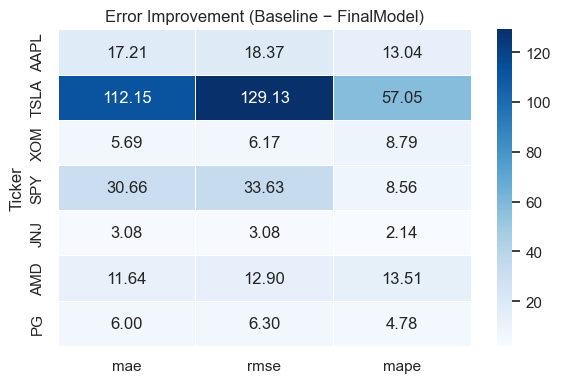

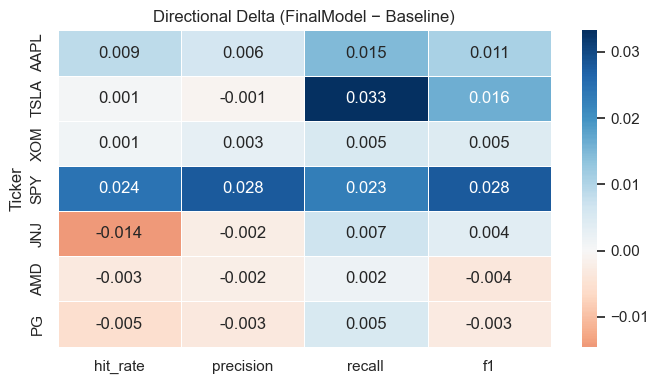

In [6]:
# ---------- 5) Heatmaps (FinalModel vs Baseline)

# Make sure both frames are indexed by ticker in the same order
if "ticker" in df3.columns:
    df3 = df3.set_index("ticker")  # FinalModel
if "ticker" in df4.columns:
    df4 = df4.set_index("ticker")  # Baseline

common_idx = df3.index.intersection(df4.index)
df3 = df3.loc[common_idx]
df4 = df4.loc[common_idx]

# ----- A) Error improvement: Baseline − FinalModel (positive = FinalModel better)
err_cols = ["mae", "rmse", "mape"]
diff_err = df4[err_cols] - df3[err_cols]
diff_err.to_csv("eval_results/heatmap_error_improvement_Baseline_minus_Final.csv")

plt.figure(figsize=(6, 4))
sns.heatmap(
    diff_err,
    annot=True,
    fmt=".2f",
    cmap="Blues",  # Single hue blue
    linewidths=0.5
)
plt.title("Error Improvement (Baseline − FinalModel)")
plt.ylabel("Ticker")
plt.tight_layout()
plt.savefig("eval_results/heatmap_error_improvement_Baseline_minus_Final.png",
            dpi=300, bbox_inches="tight")
plt.show()

# ----- B) Directional metrics delta: FinalModel − Baseline (positive = FinalModel better)
dir_cols = ["hit_rate", "precision", "recall", "f1"]
diff_dir = df3[dir_cols] - df4[dir_cols]
diff_dir.to_csv("eval_results/heatmap_directional_delta_Final_minus_Baseline.csv")

plt.figure(figsize=(7, 4))
sns.heatmap(
    diff_dir,
    annot=True,
    fmt=".3f",
    cmap="RdBu",  # Blue = positive (FinalModel better), Red = negative (Baseline better)
    center=0,
    linewidths=0.5
)
plt.title("Directional Delta (FinalModel − Baseline)")
plt.ylabel("Ticker")
plt.tight_layout()
plt.savefig("eval_results/heatmap_directional_delta_Final_minus_Baseline.png",
            dpi=300, bbox_inches="tight")
plt.show()
